Conectando ao banco e buscando dados de Mega Stones...
CSV atualizado com sucesso em: ../sql/megas_usagexwinrate.csv


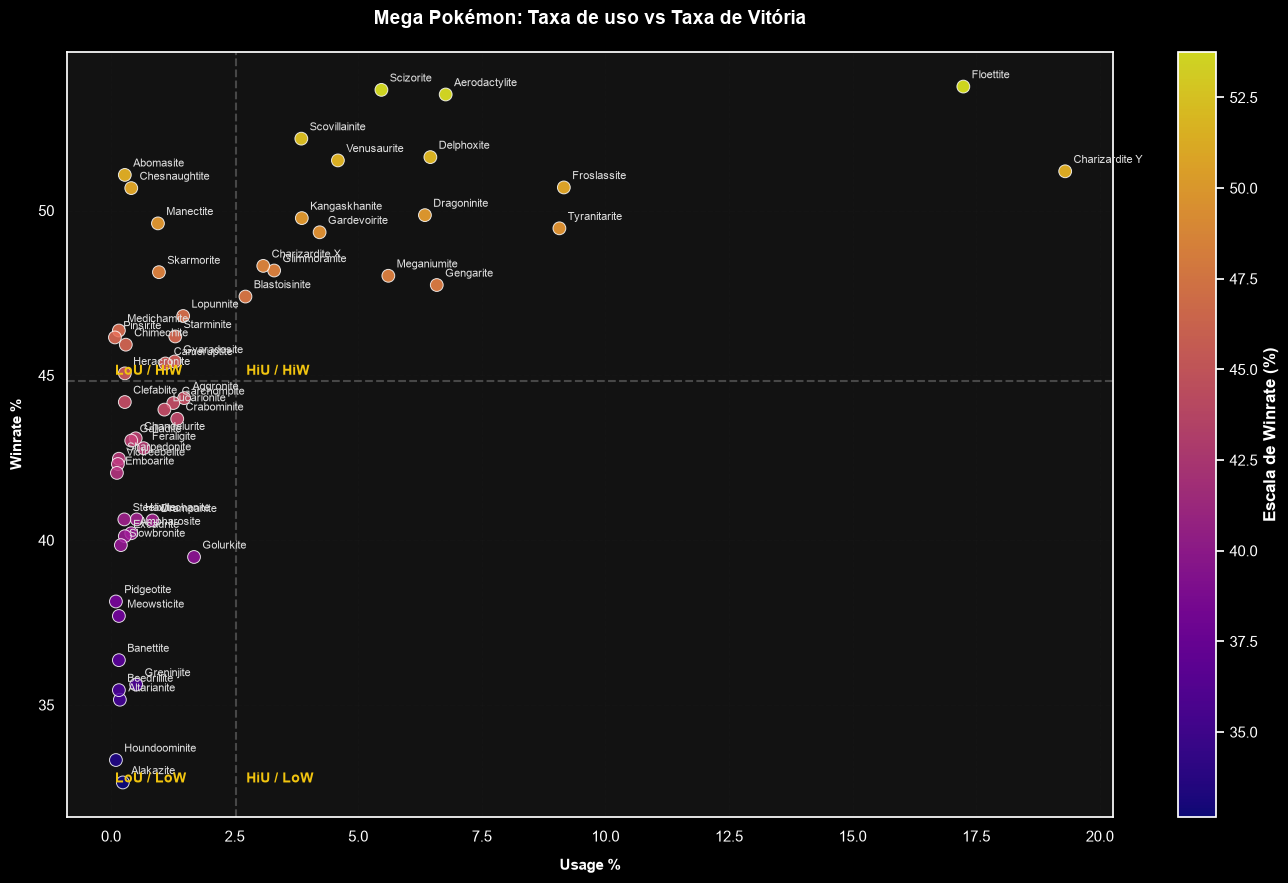

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imports.database import Database

def carregar_e_atualizar_dados():
    db = Database()

    query = """
    SELECT
        i.name AS mega_stone,
        ROUND(
            100.0 * SUM(t.wins)
            / NULLIF(SUM(t.wins) + SUM(t.losses), 0),
            2
        ) AS winrate,
        ROUND(
            100.0 * COUNT(*) /
            (SELECT COUNT(*) FROM Teams),
            2
        ) AS usage_percent
    FROM Pokemon_teams pt
    JOIN Items i ON pt.item_id = i.id
    JOIN Teams t ON pt.team_id = t.id
    WHERE
        LOWER(i.name) LIKE '%ite'
        OR LOWER(i.name) LIKE '%ite x'
        OR LOWER(i.name) LIKE '%ite y'
    GROUP BY i.name
    HAVING COUNT(*) >= 20
    ORDER BY usage_percent DESC;
    """
    
    print("Conectando ao banco e buscando dados de Mega Stones...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
    
    csv_path = "../sql/megas_usagexwinrate.csv"
    df_local.to_csv(csv_path, index=False)
    print(f"CSV atualizado com sucesso em: {csv_path}")
    
    return df_local

df = carregar_e_atualizar_dados()

plt.style.use('dark_background')
plt.figure(figsize=(14, 9))

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#121212", 
    "figure.facecolor": "#121212",
    "text.color": "white", 
    "axes.labelcolor": "white",
    "xtick.color": "white", 
    "ytick.color": "white",
    "grid.color": "#262626"
})

scatter = plt.scatter(
    df["usage_percent"],
    df["winrate"],
    c=df["winrate"],
    cmap="plasma",
    alpha=0.85,
    s=85,
    edgecolors="white",
    linewidths=0.7
)

cbar = plt.colorbar(scatter)
cbar.set_label("Escala de Winrate (%)", color="white", weight="bold")
cbar.ax.yaxis.set_tick_params(color="white")

for _, row in df.iterrows():
    plt.annotate(
        row["mega_stone"],
        (row["usage_percent"], row["winrate"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color="#E0E0E0"
    )

usage_mean = df["usage_percent"].mean()
winrate_mean = df["winrate"].mean()

plt.axvline(usage_mean, linestyle="--", linewidth=1.5, color="#555555", alpha=0.8)
plt.axhline(winrate_mean, linestyle="--", linewidth=1.5, color="#555555", alpha=0.8)

plt.text(usage_mean + 0.2, winrate_mean + 0.2, "HiU / HiW", fontsize=10, weight='bold', color="#F1C40F")
plt.text(df["usage_percent"].min(), winrate_mean + 0.2, "LoU / HiW", fontsize=10, weight='bold', color="#F1C40F")
plt.text(usage_mean + 0.2, df["winrate"].min(), "HiU / LoW", fontsize=10, weight='bold', color="#F1C40F")
plt.text(df["usage_percent"].min(), df["winrate"].min(), "LoU / LoW", fontsize=10, weight='bold', color="#F1C40F")

plt.xlabel("Usage %", weight="bold", fontsize=11, labelpad=10)
plt.ylabel("Winrate %", weight="bold", fontsize=11, labelpad=10)
plt.title("Mega Pokémon: Taxa de uso vs Taxa de Vitória", fontsize=14, weight="bold", pad=20)
plt.grid(True, linestyle="--", alpha=0.15)

plt.tight_layout()
plt.show()

Conectando ao banco e processando dados por Tipo de Mega...
Novo CSV de tipos atualizado com sucesso em: ../sql/types_megas_usagexwinrate.csv


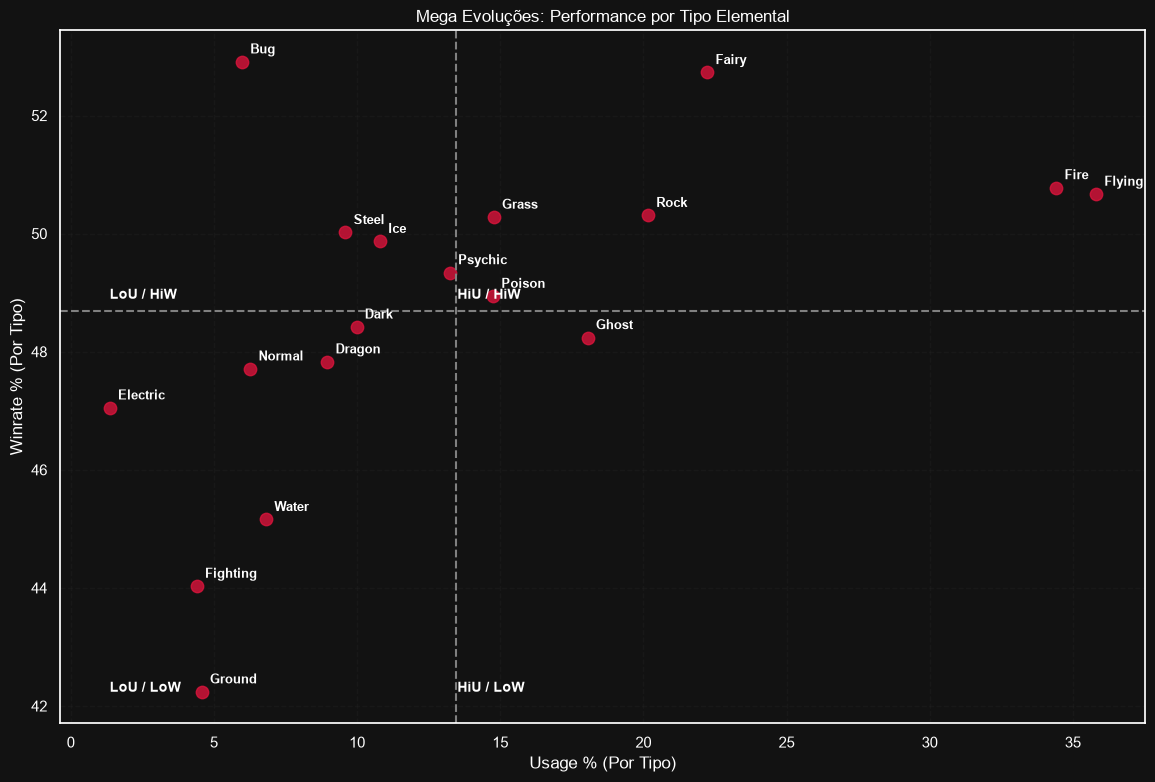

In [42]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
from imports.database import Database

def carregar_e_atualizar_dados_tipos():
    db = Database()
    
    query = """
    WITH BaseMegaTeams AS (
        SELECT 
            pt.team_id,
            t.wins,
            t.losses,
            pd.type1,
            pd.type2
        FROM Pokemon_teams pt
        JOIN Items i ON pt.item_id = i.id
        JOIN Teams t ON pt.team_id = t.id
        JOIN Pokemons p ON pt.pokemon_id = p.id
        JOIN Pokemon_mapping pm ON p.id = pm.pokemon_scraper_id
        JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
        WHERE 
            LOWER(i.name) LIKE '%ite'
            OR LOWER(i.name) LIKE '%ite x'
            OR LOWER(i.name) LIKE '%ite y'
    ),
    TypesUnfurl AS (
        SELECT team_id, wins, losses, type1 AS pokemon_type FROM BaseMegaTeams WHERE type1 IS NOT NULL
        UNION ALL
        SELECT team_id, wins, losses, type2 AS pokemon_type FROM BaseMegaTeams WHERE type2 IS NOT NULL
    )
    SELECT
        pokemon_type,
        ROUND(
            100.0 * SUM(wins)
            / NULLIF(SUM(wins) + SUM(losses), 0),
            2
        ) AS winrate,
        ROUND(
            100.0 * COUNT(DISTINCT team_id) /
            (SELECT COUNT(*) FROM Teams),
            2
        ) AS usage_percent
    FROM TypesUnfurl
    GROUP BY pokemon_type
    ORDER BY usage_percent DESC;
    """
    
    print("Conectando ao banco e processando dados por Tipo de Mega...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
        
    csv_path = "../sql/types_megas_usagexwinrate.csv"
    df_local.to_csv(csv_path, index=False)
    print(f"Novo CSV de tipos atualizado com sucesso em: {csv_path}")
    
    return df_local

df = carregar_e_atualizar_dados_tipos()

plt.figure(figsize=(14, 9))

plt.scatter(
    df["usage_percent"],
    df["winrate"],
    alpha=0.8,
    color="crimson",
    s=80
)

for _, row in df.iterrows():
    plt.annotate(
        row["pokemon_type"].capitalize(),
        (row["usage_percent"], row["winrate"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
        weight='bold'
    )

usage_mean = df["usage_percent"].mean()
winrate_mean = df["winrate"].mean()

plt.axvline(usage_mean, linestyle="--", linewidth=1.5, color="gray")
plt.axhline(winrate_mean, linestyle="--", linewidth=1.5, color="gray")

plt.text(usage_mean + 0.05, winrate_mean + 0.2, "HiU / HiW", fontsize=10, weight='bold')
plt.text(df["usage_percent"].min(), winrate_mean + 0.2, "LoU / HiW", fontsize=10, weight='bold')
plt.text(usage_mean + 0.05, df["winrate"].min(), "HiU / LoW", fontsize=10, weight='bold')
plt.text(df["usage_percent"].min(), df["winrate"].min(), "LoU / LoW", fontsize=10, weight='bold')

plt.xlabel("Usage % (Por Tipo)")
plt.ylabel("Winrate % (Por Tipo)")
plt.title("Mega Evoluções: Performance por Tipo Elemental")
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

Conectando ao banco e buscando atributos de Speed das Megas...
Novo CSV de velocidade atualizado em: ../sql/megas_speed_performance.csv


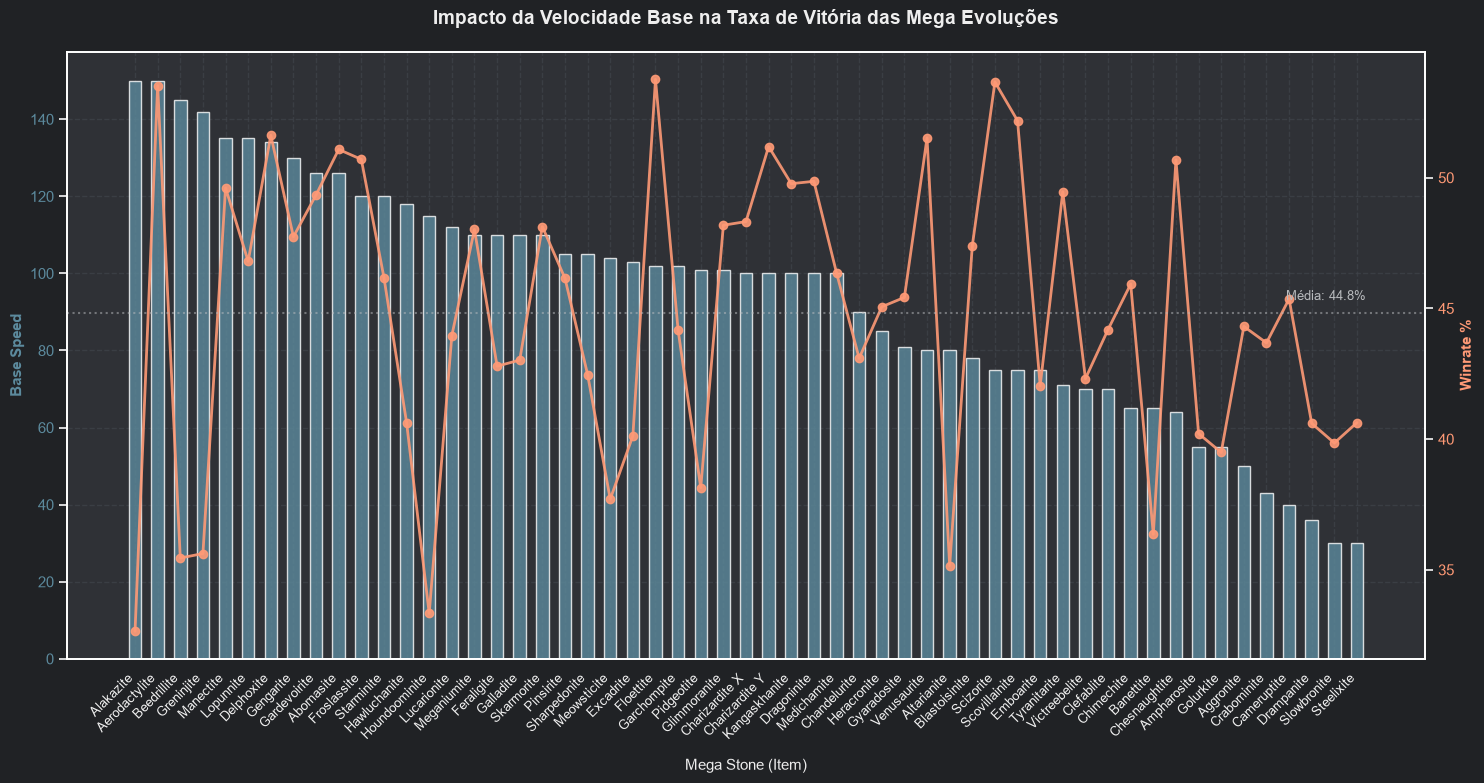

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imports.database import Database

def carregar_e_atualizar_dados_speed():
    db = Database()
    
    query = """
    SELECT
        i.name AS mega_stone,
        MAX(pd.speed) AS base_speed,
        ROUND(
            100.0 * SUM(t.wins)
            / NULLIF(SUM(t.wins) + SUM(t.losses), 0),
            2
        ) AS winrate,
        ROUND(
            100.0 * COUNT(*) /
            (SELECT COUNT(*) FROM Teams),
            2
        ) AS usage_percent
    FROM Pokemon_teams pt
    JOIN Items i ON pt.item_id = i.id
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemons p ON pt.pokemon_id = p.id
    JOIN Pokemon_mapping pm ON p.id = pm.pokemon_scraper_id
    JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
    WHERE
        LOWER(i.name) LIKE '%ite'
        OR LOWER(i.name) LIKE '%ite x'
        OR LOWER(i.name) LIKE '%ite y'
    GROUP BY i.name
    HAVING COUNT(*) >= 20
    ORDER BY base_speed DESC;
    """
    
    print("Conectando ao banco e buscando atributos de Speed das Megas...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
        
    csv_path = "../sql/megas_speed_performance.csv"
    df_local.to_csv(csv_path, index=False)
    print(f"Novo CSV de velocidade atualizado em: {csv_path}")
    
    return df_local

df = carregar_e_atualizar_dados_speed()

fig, ax1 = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('#202225')
ax1.set_facecolor('#2f3136')

cor_barra = "#5c8a9d"
cor_linha = "#ff9a76"
cor_grade = "#40444b"
cor_texto = "#eeeeee"

ax1.set_xlabel("Mega Stone (Item)", color=cor_texto, fontsize=11, labelpad=12)
ax1.set_ylabel("Base Speed", color=cor_barra, weight="bold", fontsize=11)
barras = ax1.bar(df["mega_stone"], df["base_speed"], color=cor_barra, alpha=0.8, width=0.55, label="Base Speed")
ax1.tick_params(axis="y", labelcolor=cor_barra, colors=cor_texto)
ax1.set_xticklabels(df["mega_stone"], rotation=45, ha="right", fontsize=9, color=cor_texto)
ax1.grid(True, linestyle="--", color=cor_grade, alpha=0.7)

ax2 = ax1.twinx()  
ax2.set_ylabel("Winrate %", color=cor_linha, weight="bold", fontsize=11)
linha = ax2.plot(df["mega_stone"], df["winrate"], color=cor_linha, marker="o", markersize=6, linewidth=2, alpha=0.9, label="Winrate %")
ax2.tick_params(axis="y", labelcolor=cor_linha, colors=cor_texto)

winrate_medio = df["winrate"].mean()
ax2.axhline(winrate_medio, linestyle=":", linewidth=1.5, color="#b9bbbe", alpha=0.5)
ax2.text(len(df)-0.6, winrate_medio + 0.5, f"Média: {winrate_medio:.1f}%", color="#b9bbbe", ha="right", fontsize=9)

ax2.grid(False)

plt.title("Impacto da Velocidade Base na Taxa de Vitória das Mega Evoluções", fontsize=14, weight="bold", pad=20, color=cor_texto)
fig.tight_layout()
plt.show()

Conectando ao banco e classificando as Megas por estilo de ataque...
Novo CSV de estilos de ataque atualizado em: ../sql/megas_attack_style_performance.csv


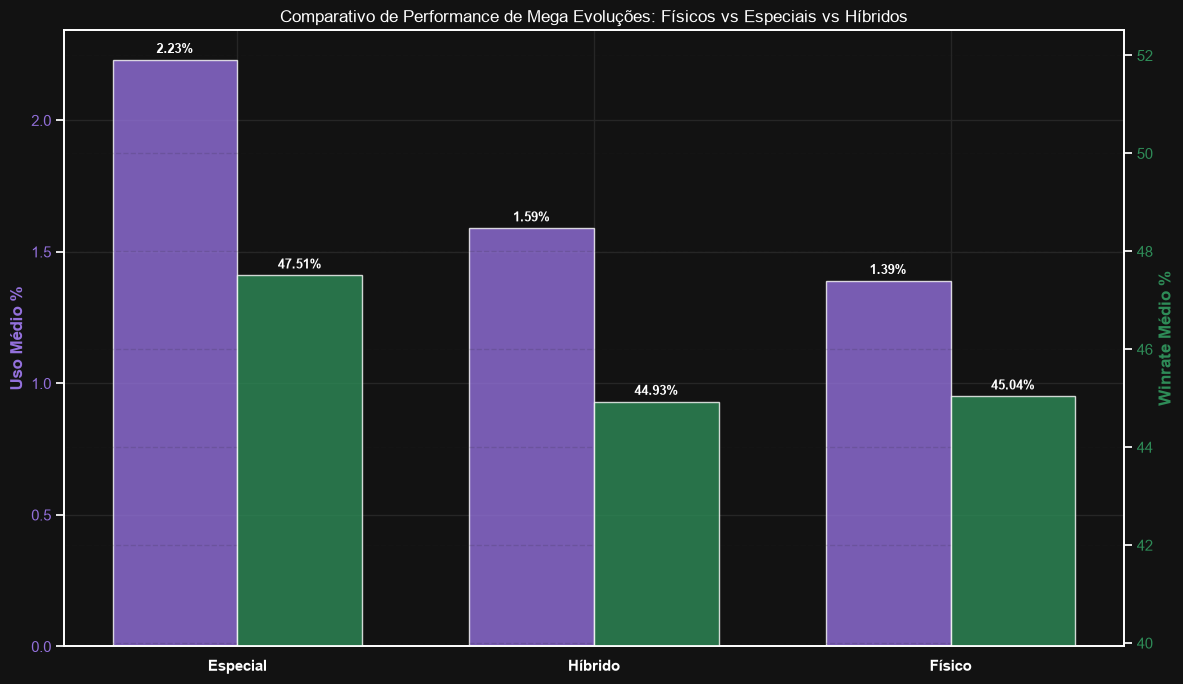

In [50]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imports.database import Database

def carregar_e_atualizar_dados_estilos():
    db = Database()
    
    query = """
    WITH MegaStats AS (
        SELECT
            i.name AS mega_stone,
            pd.attack,
            pd.special_attack,
            ROUND(
                100.0 * SUM(t.wins)
                / NULLIF(SUM(t.wins) + SUM(t.losses), 0),
                2
            ) AS winrate,
            ROUND(
                100.0 * COUNT(*) /
                (SELECT COUNT(*) FROM Teams),
                2
            ) AS usage_percent
        FROM Pokemon_teams pt
        JOIN Items i ON pt.item_id = i.id
        JOIN Teams t ON pt.team_id = t.id
        JOIN Pokemons p ON pt.pokemon_id = p.id
        JOIN Pokemon_mapping pm ON p.id = pm.pokemon_scraper_id
        JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
        WHERE
            LOWER(i.name) LIKE '%ite'
            OR LOWER(i.name) LIKE '%ite x'
            OR LOWER(i.name) LIKE '%ite y'
        GROUP BY i.name, pd.attack, pd.special_attack
        HAVING COUNT(*) >= 20
    ),
    CategorizedMegas AS (
        SELECT
            winrate,
            usage_percent,
            CASE 
                WHEN (attack - special_attack) > 20 THEN 'Físico'
                WHEN (special_attack - attack) > 20 THEN 'Especial'
                ELSE 'Híbrido'
            END AS atacante_tipo
        FROM MegaStats
    )
    SELECT
        atacante_tipo,
        ROUND(AVG(winrate), 2) AS avg_winrate,
        ROUND(AVG(usage_percent), 2) AS avg_usage
    FROM CategorizedMegas
    GROUP BY atacante_tipo
    ORDER BY avg_usage DESC;
    """
    
    print("Conectando ao banco e classificando as Megas por estilo de ataque...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
        
    csv_path = "../sql/megas_attack_style_performance.csv"
    df_local.to_csv(csv_path, index=False)
    print(f"Novo CSV de estilos de ataque atualizado em: {csv_path}")
    
    return df_local

df = carregar_e_atualizar_dados_estilos()

categorias = df["atacante_tipo"].tolist()
valores_uso = df["avg_usage"].tolist()
valores_vitoria = df["avg_winrate"].tolist()

x = np.arange(len(categorias))
largura = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

cor_uso = "mediumpurple"
barra1 = ax1.bar(x - largura/2, valores_uso, largura, label="Uso Médio %", color=cor_uso, alpha=0.8)
ax1.set_ylabel("Uso Médio %", color=cor_uso, weight="bold")
ax1.tick_params(axis="y", labelcolor=cor_uso)
ax1.set_xticks(x)
ax1.set_xticklabels(categorias, fontsize=11, weight="bold")

ax2 = ax1.twinx()

cor_vitoria = "seagreen"
barra2 = ax2.bar(x + largura/2, valores_vitoria, largura, label="Winrate Médio %", color=cor_vitoria, alpha=0.8)
ax2.set_ylabel("Winrate Médio %", color=cor_vitoria, weight="bold")
ax2.tick_params(axis="y", labelcolor=cor_vitoria)

ax2.set_ylim(min(valores_vitoria) - 5, max(valores_vitoria) + 5)

for barra in barra1:
    altura = barra.get_height()
    ax1.annotate(f'{altura}%',
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 3),  
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, weight="bold")

for barra in barra2:
    altura = barra.get_height()
    ax2.annotate(f'{altura}%',
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, weight="bold")

plt.title("Comparativo de Performance de Mega Evoluções: Físicos vs Especiais vs Híbridos")
fig.tight_layout()
plt.grid(True, linestyle="--", alpha=0.15)

plt.show()

Conectando ao banco e contando Megas por time...


C:\Users\User\AppData\Local\Temp\ipykernel_2860\4066763752.py:61: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_local = pd.read_sql_query(query, conexao)


Novo CSV de quantidade de Megas atualizado em: ../sql/megas_count_performance.csv


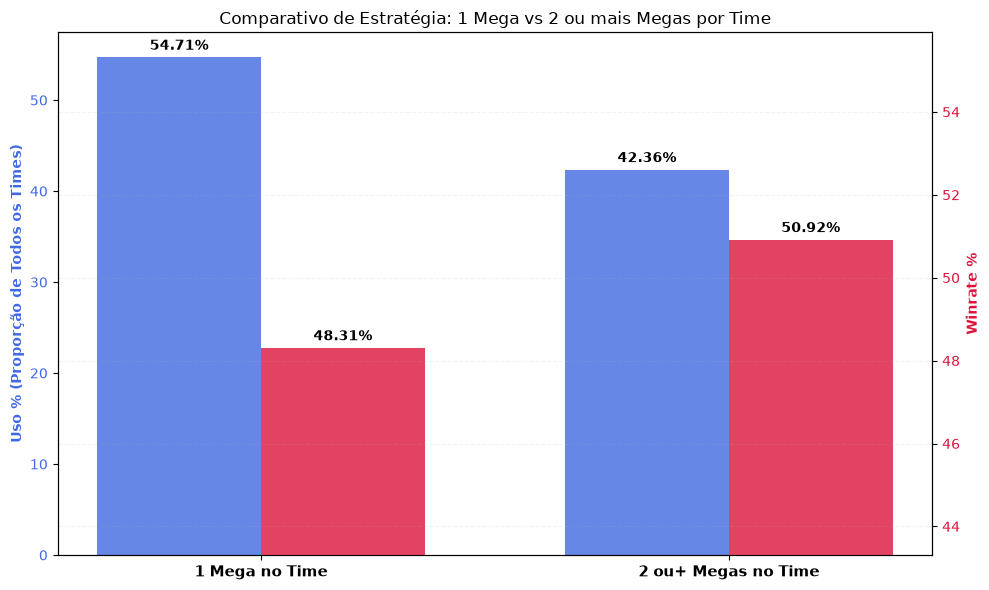

In [11]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imports.database import Database

def carregar_e_atualizar_dados_quantidade():
    db = Database()
    
    query = """
    WITH TeamMegaCount AS (
        SELECT
            t.id AS team_id,
            t.wins,
            t.losses,
            COUNT(pt.pokemon_id) AS mega_count
        FROM Teams t
        JOIN Pokemon_teams pt ON t.id = pt.team_id
        JOIN Items i ON pt.item_id = i.id
        WHERE
            LOWER(i.name) LIKE '%ite'
            OR LOWER(i.name) LIKE '%ite x'
            OR LOWER(i.name) LIKE '%ite y'
        GROUP BY t.id, t.wins, t.losses
    ),
    CategorizedTeams AS (
        SELECT
            wins,
            losses,
            CASE 
                WHEN mega_count = 1 THEN '1 Mega no Time'
                ELSE '2 ou+ Megas no Time'
            END AS qtd_megas
        FROM TeamMegaCount
    ),
    MetricsPerCategory AS (
        SELECT
            qtd_megas,
            ROUND(
                100.0 * SUM(wins)
                / NULLIF(SUM(wins) + SUM(losses), 0),
                2
            ) AS winrate,
            ROUND(
                100.0 * COUNT(*) /
                (SELECT COUNT(*) FROM Teams),
                2
            ) AS usage_percent
        FROM CategorizedTeams
        GROUP BY qtd_megas
    )
    SELECT * FROM MetricsPerCategory
    ORDER BY usage_percent DESC;
    """
    
    print("Conectando ao banco e contando Megas por time...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
        
    csv_path = "../sql/megas_count_performance.csv"
    df_local.to_csv(csv_path, index=False)
    print(f"Novo CSV de quantidade de Megas atualizado em: {csv_path}")
    
    return df_local

df = carregar_e_atualizar_dados_quantidade()

categorias = df["qtd_megas"].tolist()
valores_uso = df["usage_percent"].tolist()
valores_vitoria = df["winrate"].tolist()

x = np.arange(len(categorias))
largura = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

cor_uso = "royalblue"
barra1 = ax1.bar(x - largura/2, valores_uso, largura, label="Uso %", color=cor_uso, alpha=0.8)
ax1.set_ylabel("Uso % (Proporção de Todos os Times)", color=cor_uso, weight="bold")
ax1.tick_params(axis="y", labelcolor=cor_uso)
ax1.set_xticks(x)
ax1.set_xticklabels(categorias, fontsize=11, weight="bold")

ax2 = ax1.twinx()

cor_vitoria = "crimson"
barra2 = ax2.bar(x + largura/2, valores_vitoria, largura, label="Winrate %", color=cor_vitoria, alpha=0.8)
ax2.set_ylabel("Winrate %", color=cor_vitoria, weight="bold")
ax2.tick_params(axis="y", labelcolor=cor_vitoria)

ax2.set_ylim(min(valores_vitoria) - 5, max(valores_vitoria) + 5)

for barra in barra1:
    altura = barra.get_height()
    ax1.annotate(f'{altura}%',
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 3),  
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, weight="bold")

for barra in barra2:
    altura = barra.get_height()
    ax2.annotate(f'{altura}%',
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, weight="bold")

plt.title("Comparativo de Estratégia: 1 Mega vs 2 ou mais Megas por Time")
fig.tight_layout()
plt.grid(True, linestyle="--", alpha=0.15)

plt.show()

Conectando ao banco e calculando cruzamento de tipos nos times com 2 Megas...


C:\Users\User\AppData\Local\Temp\ipykernel_3140\2469147500.py:62: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_local = pd.read_sql_query(query, conexao)


Novo CSV de combinação de tipos salvo em: ../sql/megas_double_type_combinations.csv


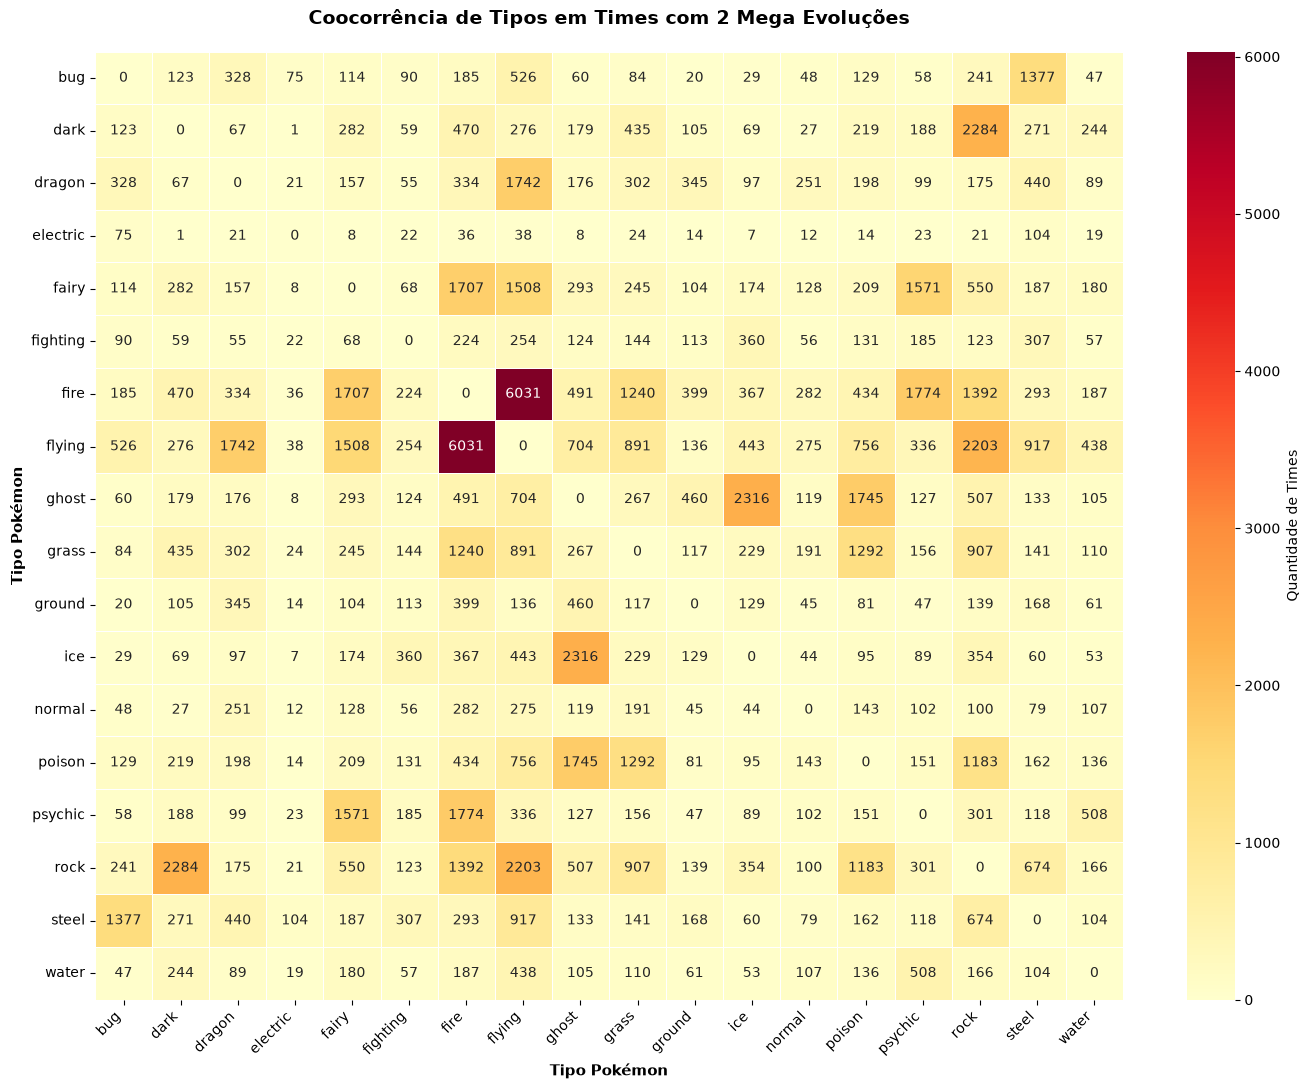

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imports.database import Database

def carregar_dados_combinacao_tipos():
    db = Database()
    
    query = """
    WITH TeamMegaCount AS (
        SELECT
            t.id AS team_id
        FROM Teams t
        JOIN Pokemon_teams pt ON t.id = pt.team_id
        JOIN Items i ON pt.item_id = i.id
        WHERE
            LOWER(i.name) LIKE '%ite'
            OR LOWER(i.name) LIKE '%ite x'
            OR LOWER(i.name) LIKE '%ite y'
        GROUP BY t.id
        HAVING COUNT(pt.pokemon_id) = 2
    ),
    MegaPokemonStats AS (
        SELECT 
            pt.team_id,
            pd.type1,
            pd.type2
        FROM Pokemon_teams pt
        JOIN Items i ON pt.item_id = i.id
        JOIN Pokemon_mapping pm ON pt.pokemon_id = pm.pokemon_scraper_id
        JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
        WHERE
            LOWER(i.name) LIKE '%ite'
            OR LOWER(i.name) LIKE '%ite x'
            OR LOWER(i.name) LIKE '%ite y'
    ),
    -- Expandimos type1 e type2 em linhas separadas para capturar todos os tipos de cada Mega no time
    ExpandedTypes AS (
        SELECT team_id, type1 AS type_name FROM MegaPokemonStats WHERE type1 IS NOT NULL
        UNION ALL
        SELECT team_id, type2 AS type_name FROM MegaPokemonStats WHERE type2 IS NOT NULL
    )
    -- Fazemos um self-join para cruzar cada tipo com todos os outros tipos do MESMO time
    SELECT 
        t1.type_name AS tipo_a,
        t2.type_name AS tipo_b,
        COUNT(DISTINCT t1.team_id) AS quantidade_times
    FROM ExpandedTypes t1
    JOIN ExpandedTypes t2 ON t1.team_id = t2.team_id
    WHERE t1.type_name != t2.type_name -- Remove a contagem do tipo com ele mesmo no mesmo slot
    GROUP BY t1.type_name, t2.type_name;
    """
    
    print("Conectando ao banco e calculando cruzamento de tipos nos times com 2 Megas...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
        
    csv_path = "../sql/megas_double_type_combinations.csv"
    df_local.to_csv(csv_path, index=False)
    print(f"Novo CSV de combinação de tipos salvo em: {csv_path}")
    
    return df_local

df = carregar_dados_combinacao_tipos()

matrix_dados = df.pivot(index="tipo_a", columns="tipo_b", values="quantidade_times").fillna(0)

plt.figure(figsize=(14, 11))
sns.heatmap(
    matrix_dados, 
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=.5,
    cbar_kws={'label': 'Quantidade de Times'}
)

plt.title("Coocorrência de Tipos em Times com 2 Mega Evoluções", fontsize=14, weight="bold", pad=20)
plt.xlabel("Tipo Pokémon", fontsize=11, weight="bold")
plt.ylabel("Tipo Pokémon", fontsize=11, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Conectando ao banco e calculando winrates do meta expandido...
Novo CSV salvo em: ../sql/winrate_vs_counters_meta.csv


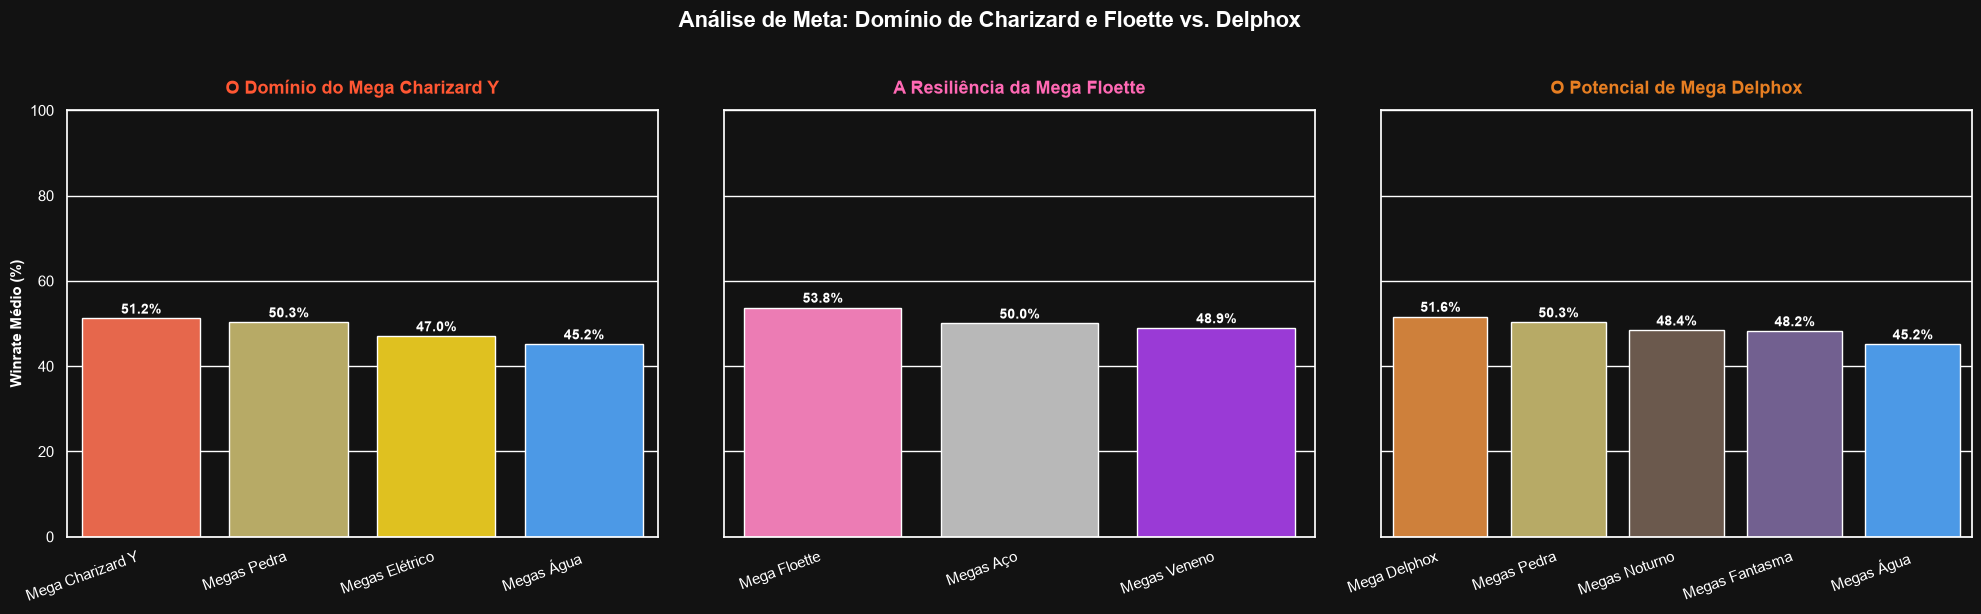

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imports.database import Database

def carregar_dados_winrate_counters():
    db = Database()
    
    query = """
    WITH BaseStats AS (
        SELECT 
            pt.team_id,
            t.wins,
            t.losses,
            pd.name AS pokemon_name,
            pd.type1,
            pd.type2,
            i.name AS item_name
        FROM Pokemon_teams pt
        JOIN Teams t ON pt.team_id = t.id
        JOIN Items i ON pt.item_id = i.id
        JOIN Pokemon_mapping pm ON pt.pokemon_id = pm.pokemon_scraper_id
        JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
        WHERE LOWER(i.name) LIKE '%ite' 
           OR LOWER(i.name) LIKE '%ite x' 
           OR LOWER(i.name) LIKE '%ite y'
    ),
    Categorias_Stats AS (
        -- 1. Mega Charizard Y
        SELECT 'Mega Charizard Y' AS categoria, 'Charizard Y & Counters' AS grupo, '#FF5733' AS cor, wins, losses FROM BaseStats WHERE LOWER(pokemon_name) LIKE '%charizard%' AND LOWER(item_name) LIKE '%charizardite y'
        UNION ALL
        SELECT 'Megas Pedra' AS categoria, 'Charizard Y & Counters' AS grupo, '#C5B358' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Rock' OR type2 = 'Rock'
        UNION ALL
        SELECT 'Megas Elétrico' AS categoria, 'Charizard Y & Counters' AS grupo, '#FFD700' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Electric' OR type2 = 'Electric'
        UNION ALL
        SELECT 'Megas Água' AS categoria, 'Charizard Y & Counters' AS grupo, '#3399FF' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Water' OR type2 = 'Water'
        
        UNION ALL
        -- 2. Mega Floette
        SELECT 'Mega Floette' AS categoria, 'Mega Floette & Counters' AS grupo, '#FF69B4' AS cor, wins, losses FROM BaseStats WHERE LOWER(pokemon_name) LIKE '%floette%'
        UNION ALL
        SELECT 'Megas Veneno' AS categoria, 'Mega Floette & Counters' AS grupo, '#A020F0' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Poison' OR type2 = 'Poison'
        UNION ALL
        SELECT 'Megas Aço' AS categoria, 'Mega Floette & Counters' AS grupo, '#B8B8B8' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Steel' OR type2 = 'Steel'
        
        UNION ALL
        -- 3. Mega Delphox e suas ameaças (Rock, Water, Ghost, Dark)
        SELECT 'Mega Delphox' AS categoria, 'Mega Delphox & Counters' AS grupo, '#E67E22' AS cor, wins, losses FROM BaseStats WHERE LOWER(pokemon_name) LIKE '%delphox%' AND LOWER(item_name) LIKE '%delphoxite%'
        UNION ALL
        SELECT 'Megas Pedra' AS categoria, 'Mega Delphox & Counters' AS grupo, '#C5B358' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Rock' OR type2 = 'Rock'
        UNION ALL
        SELECT 'Megas Água' AS categoria, 'Mega Delphox & Counters' AS grupo, '#3399FF' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Water' OR type2 = 'Water'
        UNION ALL
        SELECT 'Megas Fantasma' AS categoria, 'Mega Delphox & Counters' AS grupo, '#705898' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Ghost' OR type2 = 'Ghost'
        UNION ALL
        SELECT 'Megas Noturno' AS categoria, 'Mega Delphox & Counters' AS grupo, '#705848' AS cor, wins, losses FROM BaseStats WHERE type1 = 'Dark' OR type2 = 'Dark'
    )
    SELECT 
        categoria,
        grupo,
        cor,
        ROUND(
            100.0 * SUM(wins) / NULLIF(SUM(wins) + SUM(losses), 0), 
            2
        ) AS winrate
    FROM Categorias_Stats
    GROUP BY categoria, grupo, cor;
    """
    
    print("Conectando ao banco e calculando winrates do meta expandido...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
        
    csv_path = "../sql/winrate_vs_counters_meta.csv"
    df_local.to_csv(csv_path, index=False)
    print(f"Novo CSV salvo em: {csv_path}")
    
    return df_local

df = carregar_dados_winrate_counters()

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#121212", 
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Análise de Meta: Domínio de Charizard e Floette vs. Delphox', fontsize=16, fontweight='bold', color='#FFFFFF', y=1.02)

df_chari = df[df['grupo'] == 'Charizard Y & Counters'].sort_values(by='winrate', ascending=False)
if not df_chari.empty:
    sns.barplot(x='categoria', y='winrate', data=df_chari, palette=df_chari['cor'].tolist(), ax=axes[0], hue='categoria', legend=False)
    axes[0].set_xticklabels(df_chari['categoria'], rotation=20, ha='right', color='white')
axes[0].set_title('O Domínio do Mega Charizard Y', fontsize=13, color='#FF5733', weight='bold', pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Winrate Médio (%)', fontsize=11, weight='bold', color='white')

df_floette = df[df['grupo'] == 'Mega Floette & Counters'].sort_values(by='winrate', ascending=False)
if not df_floette.empty:
    sns.barplot(x='categoria', y='winrate', data=df_floette, palette=df_floette['cor'].tolist(), ax=axes[1], hue='categoria', legend=False)
    axes[1].set_xticklabels(df_floette['categoria'], rotation=20, ha='right', color='white')
axes[1].set_title('A Resiliência da Mega Floette', fontsize=13, color='#FF69B4', weight='bold', pad=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('')

df_delphox = df[df['grupo'] == 'Mega Delphox & Counters'].sort_values(by='winrate', ascending=False)
if not df_delphox.empty:
    sns.barplot(x='categoria', y='winrate', data=df_delphox, palette=df_delphox['cor'].tolist(), ax=axes[2], hue='categoria', legend=False)
    axes[2].set_xticklabels(df_delphox['categoria'], rotation=20, ha='right', color='white')
axes[2].set_title('O Potencial de Mega Delphox', fontsize=13, color='#E67E22', weight='bold', pad=12)
axes[2].set_xlabel('')
axes[2].set_ylabel('')

for ax in axes:
    ax.tick_params(colors='white', which='both')
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                        ha='center', va='center', xytext=(0, 3), textcoords='offset points', fontsize=10, fontweight='bold', color='white')

plt.ylim(0, 100)
plt.tight_layout()

plt.savefig('../sql/winrate_counters_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def analisar_meta_delphox_profundo():
    db = Database()

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    query_times = """
    SELECT 
        pt.team_id, 
        t.wins, 
        t.losses
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pm ON pt.pokemon_id = pm.pokemon_scraper_id
    JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
    WHERE LOWER(pd.name) LIKE '%delphox%';
    """
    
    print("🔮 Conectando ao banco e localizando todos os times com Delphox...")
    with db.connect() as cursor:
        df_times = pd.read_sql_query(query_times, cursor._connection)
        
    if df_times.empty:
        print("❌ Nenhum time encontrado com Delphox nos dados atuais.")
        return

    total_teams = len(df_times)
    total_wins = df_times['wins'].sum()
    total_losses = df_times['losses'].sum()
    total_games = total_wins + total_losses
    winrate_geral = (total_wins / total_games) * 100 if total_games > 0 else 0.0
    
    print(f"✅ Encontrado(s) {total_teams} time(s) centrados na Delphox!")
    print(f"📊 Desempenho Geral da Raposa: {total_games} partidas ({total_wins}V - {total_losses}D) | Winrate: {winrate_geral:.2f}%\n")

    team_ids = df_times['team_id'].tolist()
    where_clause = f"WHERE pt.team_id = {team_ids[0]}" if len(team_ids) == 1 else f"WHERE pt.team_id IN {tuple(team_ids)}"

    query_companheiros = f"""
    SELECT 
        pt.team_id,
        pdata.name AS pokemon_name,
        t.wins,
        t.losses
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    {where_clause}
      AND LOWER(pdata.name) NOT LIKE '%delphox%';
    """
    
    print("👥 Calculando a sinergia e popularidade dos parceiros de equipe...")
    with db.connect() as cursor:
        df_comps = pd.read_sql_query(query_companheiros, cursor._connection)
        
    if df_comps.empty:
        print("⚠️ Não foram encontrados outros Pokémon registrados com a Delphox.")
        return

    agg_comps = df_comps.groupby('pokemon_name').agg(
        aparicoes=('team_id', 'count'),
        vitorias=('wins', 'sum'),
        derrotas=('losses', 'sum')
    ).reset_index()
    
    agg_comps['Presença nos Times (%)'] = (agg_comps['aparicoes'] / total_teams) * 100
    agg_comps['Winrate do Duo (%)'] = (agg_comps['vitorias'] / (agg_comps['vitorias'] + agg_comps['derrotas'])) * 100
    agg_comps = agg_comps.sort_values(by='Presença nos Times (%)', ascending=False)
    
    print("\n👑 TOP COMPANHEIROS MAIS POPULARES:")
    print(agg_comps[['pokemon_name', 'aparicoes', 'Presença nos Times (%)', 'Winrate do Duo (%)']].head(20).to_string(index=False))

    top_pokemon_alvos = ['Delphox'] + agg_comps['pokemon_name'].head(20).tolist()

    query_builds = f"""
    SELECT 
        pt.id AS pokemon_team_id,
        pdata.name AS pokemon_name,
        i.name AS item_name,
        mdata.name AS move_name,
        mdata.damage_class,
        t.wins,
        t.losses
    FROM Pokemon_moves pm
    JOIN Pokemon_teams pt ON pm.idpokemon_team = pt.id
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    JOIN Items i ON pt.item_id = i.id
    JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    JOIN Moves_data mdata ON mm.move_api_id = mdata.id
    {where_clause};
    """

    print("\n📦 Carregando e mapeando cruzamentos de Itens e Movimentos...")
    with db.connect() as cursor:
        df_builds = pd.read_sql_query(query_builds, cursor._connection)

    output_lines = []

    for poke in top_pokemon_alvos:
        df_poke = df_builds[df_builds['pokemon_name'].str.lower() == poke.lower()]
        if df_poke.empty:
            continue

        output_lines.append(f"\n==================================================")
        output_lines.append(f"Nome do pokemon: {poke.upper()}")
        output_lines.append(f"==================================================")

        df_unique_pokes = df_poke.drop_duplicates(subset=['pokemon_team_id'])
        total_poke_teams = len(df_unique_pokes)

        df_items_agg = df_unique_pokes.groupby('item_name').agg(
            qtd=('pokemon_team_id', 'count'),
            v_total=('wins', 'sum'),
            d_total=('losses', 'sum')
        ).reset_index()

        df_items_agg['uso_pct'] = (df_items_agg['qtd'] / total_poke_teams) * 100
        df_items_agg['winrate_pct'] = (df_items_agg['v_total'] / (df_items_agg['v_total'] + df_items_agg['d_total'])) * 100
        df_top_items = df_items_agg.sort_values(by='uso_pct', ascending=False).head(5)

        output_lines.append("Lista de itens mais usados:")
        
        for _, item_row in df_top_items.iterrows():
            item_name = item_row['item_name']
            uso = item_row['uso_pct']
            wr = item_row['winrate_pct']
            
            output_lines.append(f"  ↳ Item: {item_name} | Uso: {uso:.2f}% | Winrate: {wr:.2f}%")
            output_lines.append(f"    Movimentos mais usados com {item_name}:")

            df_item_moves = df_poke[df_poke['item_name'] == item_name]
            
            top_moves = df_item_moves['move_name'].value_counts().head(6).reset_index()
            top_moves.columns = ['move_name', 'count']

            for _, move_row in top_moves.iterrows():
                m_name = move_row['move_name']
                m_count = move_row['count']
                m_class = df_item_moves[df_item_moves['move_name'] == m_name]['damage_class'].iloc[0]
                
                output_lines.append(f"      nome: {m_name:<18} | qtd vezes: {m_count:<4} | classe: {m_class}")
            output_lines.append("")

    print("\n".join(output_lines))

analisar_meta_delphox_profundo()

🔮 Conectando ao banco e localizando todos os times com Delphox...
✅ Encontrado(s) 1634 time(s) centrados na Delphox!
📊 Desempenho Geral da Raposa: 9180 partidas (4724V - 4456D) | Winrate: 51.46%

👥 Calculando a sinergia e popularidade dos parceiros de equipe...

👑 TOP COMPANHEIROS MAIS POPULARES:
           pokemon_name  aparicoes  Presença nos Times (%)  Winrate do Duo (%)
               sneasler       1065               65.177479           52.386515
               garchomp        953               58.323133           52.244596
              kingambit        832               50.917993           54.730713
       basculegion-male        491               30.048960           54.679803
             aerodactyl        436               26.682987           51.472368
              sinistcha        353               21.603427           50.941423
        floette-eternal        322               19.706242           54.870666
             incineroar        300               18.359853           5

🔮 Buscando e cruzando dados de suporte de Tailwind nos times com Delphox...


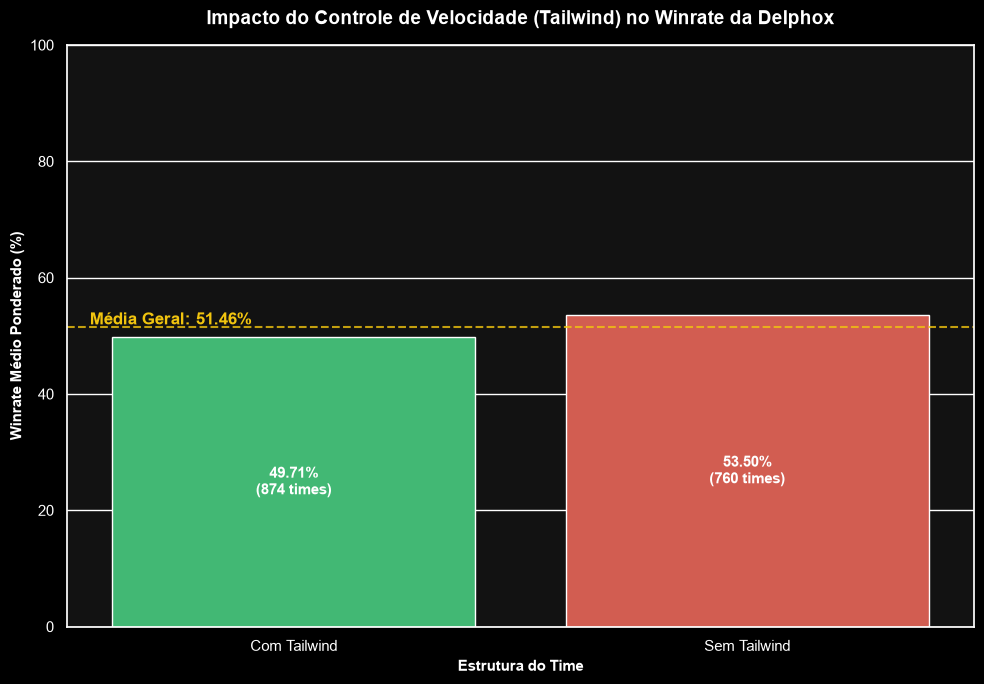

In [16]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def gerar_grafico_tailwind_delphox():
    db = Database()

    query_base = """
    SELECT 
        pt.team_id,
        t.wins,
        t.losses,
        mdata.name AS move_name
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    LEFT JOIN Pokemon_moves pm ON pt.id = pm.idpokemon_team
    LEFT JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    LEFT JOIN Moves_data mdata ON mm.move_api_id = mdata.id
    WHERE pt.team_id IN (
        SELECT DISTINCT pt2.team_id
        FROM Pokemon_teams pt2
        JOIN Pokemon_mapping pm2 ON pt2.pokemon_id = pm2.pokemon_scraper_id
        JOIN Pokemon_data pd2 ON pm2.pokemon_api_id = pd2.id
        WHERE LOWER(pd2.name) LIKE '%delphox%'
    );
    """
    
    print("🔮 Buscando e cruzando dados de suporte de Tailwind nos times com Delphox...")
    with db.connect() as cursor:
        df = pd.read_sql_query(query_base, cursor._connection)

    if df.empty:
        print("❌ Nenhum dado encontrado para processar.")
        return

    teams_com_tailwind = set(df[df['move_name'].str.lower() == 'tailwind']['team_id'].unique())

    df_teams_unicos = df.drop_duplicates(subset=['team_id']).copy()
    df_teams_unicos['possui_tailwind'] = df_teams_unicos['team_id'].apply(
        lambda x: 'Com Tailwind' if x in teams_com_tailwind else 'Sem Tailwind'
    )

    df_agrupado = df_teams_unicos.groupby('possui_tailwind').agg(
        vitorias=('wins', 'sum'),
        derrotas=('losses', 'sum'),
        qtd_times=('team_id', 'count')
    ).reset_index()

    df_agrupado['winrate'] = (df_agrupado['vitorias'] / (df_agrupado['vitorias'] + df_agrupado['derrotas'])) * 100

    total_v = df_agrupado['vitorias'].sum()
    total_d = df_agrupado['derrotas'].sum()
    media_geral_winrate = (total_v / (total_v + total_d)) * 100

    plt.style.use('dark_background')
    plt.figure(figsize=(10, 7))
    
    sns.set_theme(style="darkgrid", rc={
        "axes.facecolor": "#121212", "figure.facecolor": "#121212",
        "text.color": "white", "axes.labelcolor": "white",
        "xtick.color": "white", "ytick.color": "white"
    })

    cores = ['#2ECC71' if x == 'Com Tailwind' else '#E74C3C' for x in df_agrupado['possui_tailwind']]
    
    ax = sns.barplot(
        x='possui_tailwind', 
        y='winrate', 
        data=df_agrupado, 
        palette=cores, 
        hue='possui_tailwind', 
        legend=False
    )
    
    plt.axhline(media_geral_winrate, color='#F1C40F', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.text(-0.45, media_geral_winrate + 0.5, f"Média Geral: {media_geral_winrate:.2f}%", color='#F1C40F', weight='bold')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            tipo = df_agrupado['possui_tailwind'].iloc[int(p.get_x() + 0.5)]
            qtd = df_agrupado[df_agrupado['possui_tailwind'] == tipo]['qtd_times'].iloc[0]
            ax.annotate(f"{height:.2f}%\n({qtd} times)", (p.get_x() + p.get_width() / 2., height / 2),
                        ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    plt.title("Impacto do Controle de Velocidade (Tailwind) no Winrate da Delphox", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Estrutura do Time", weight='bold', fontsize=11)
    plt.ylabel("Winrate Médio Ponderado (%)", weight='bold', fontsize=11)
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()

gerar_grafico_tailwind_delphox()

🔮 Buscando e cruzando dados de suporte de Redirection nos times com Delphox...


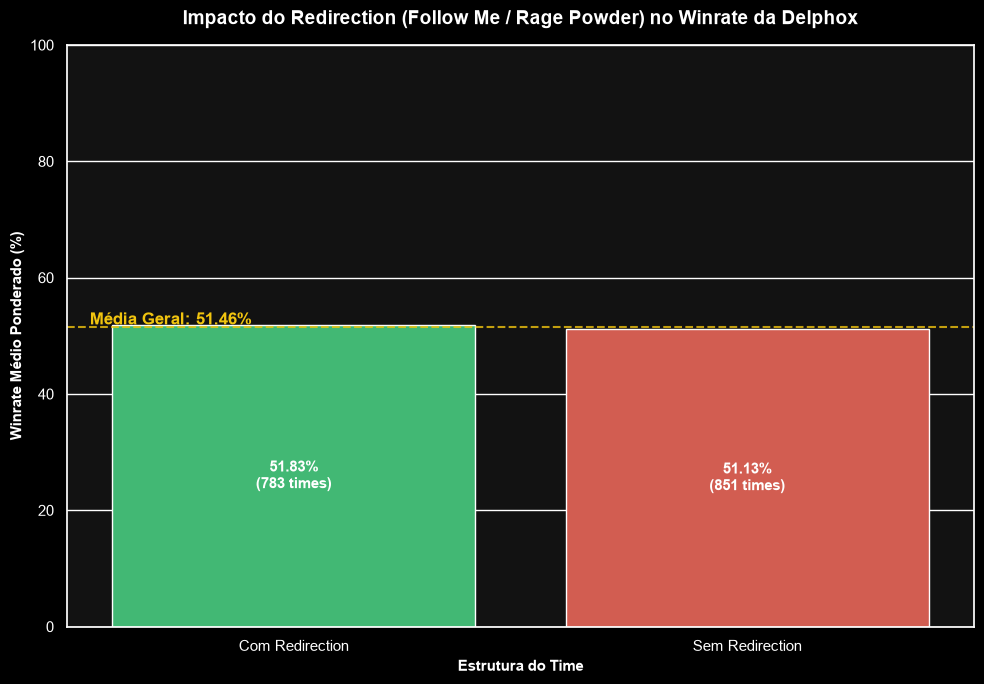

In [26]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def gerar_grafico_redirection_delphox():
    db = Database()

    query_base = """
    SELECT 
        pt.team_id,
        t.wins,
        t.losses,
        mdata.name AS move_name
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    LEFT JOIN Pokemon_moves pm ON pt.id = pm.idpokemon_team
    LEFT JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    LEFT JOIN Moves_data mdata ON mm.move_api_id = mdata.id
    WHERE pt.team_id IN (
        SELECT DISTINCT pt2.team_id
        FROM Pokemon_teams pt2
        JOIN Pokemon_mapping pm2 ON pt2.pokemon_id = pm2.pokemon_scraper_id
        JOIN Pokemon_data pd2 ON pm2.pokemon_api_id = pd2.id
        WHERE LOWER(pd2.name) LIKE '%delphox%'
    );
    """
    
    print("🔮 Buscando e cruzando dados de suporte de Redirection nos times com Delphox...")
    with db.connect() as cursor:
        df = pd.read_sql_query(query_base, cursor._connection)

    if df.empty:
        print("❌ Nenhum dado encontrado para processar.")
        return

    df['move_clean'] = df['move_name'].fillna('').str.lower().str.replace('-', ' ').str.strip()

    movimentos_redirection = {'follow me', 'rage powder'}
    teams_com_redirection = set(df[df['move_clean'].isin(movimentos_redirection)]['team_id'].unique())

    df_teams_unicos = df.drop_duplicates(subset=['team_id']).copy()
    df_teams_unicos['possui_redirection'] = df_teams_unicos['team_id'].apply(
        lambda x: 'Com Redirection' if x in teams_com_redirection else 'Sem Redirection'
    )

    df_agrupado = df_teams_unicos.groupby('possui_redirection').agg(
        vitorias=('wins', 'sum'),
        derrotas=('losses', 'sum'),
        qtd_times=('team_id', 'count')
    ).reset_index()

    todas_categorias = pd.DataFrame({'possui_redirection': ['Com Redirection', 'Sem Redirection']})
    df_agrupado = pd.merge(todas_categorias, df_agrupado, on='possui_redirection', how='left').fillna(0)

    df_agrupado['winrate'] = 0.0
    mask = (df_agrupado['vitorias'] + df_agrupado['derrotas']) > 0
    df_agrupado.loc[mask, 'winrate'] = (df_agrupado['vitorias'] / (df_agrupado['vitorias'] + df_agrupado['derrotas'])) * 100

    total_v = df_agrupado['vitorias'].sum()
    total_d = df_agrupado['derrotas'].sum()
    media_geral_winrate = (total_v / (total_v + total_d)) * 100 if (total_v + total_d) > 0 else 0

    plt.style.use('dark_background')
    plt.figure(figsize=(10, 7))
    
    sns.set_theme(style="darkgrid", rc={
        "axes.facecolor": "#121212", "figure.facecolor": "#121212",
        "text.color": "white", "axes.labelcolor": "white",
        "xtick.color": "white", "ytick.color": "white"
    })

    cores = ['#2ECC71' if x == 'Com Redirection' else '#E74C3C' for x in df_agrupado['possui_redirection']]
    
    ax = sns.barplot(
        x='possui_redirection', 
        y='winrate', 
        data=df_agrupado, 
        palette=cores, 
        hue='possui_redirection', 
        legend=False
    )
    
    if media_geral_winrate > 0:
        plt.axhline(media_geral_winrate, color='#F1C40F', linestyle='--', linewidth=1.5, alpha=0.8)
        plt.text(-0.45, media_geral_winrate + 0.5, f"Média Geral: {media_geral_winrate:.2f}%", color='#F1C40F', weight='bold')

    for p in ax.patches:
        height = p.get_height()
        tipo = df_agrupado['possui_redirection'].iloc[int(p.get_x() + 0.5)]
        qtd = int(df_agrupado[df_agrupado['possui_redirection'] == tipo]['qtd_times'].iloc[0])
        ax.annotate(f"{height:.2f}%\n({qtd} times)", (p.get_x() + p.get_width() / 2., max(height / 2, 5)),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    plt.title("Impacto do Redirection (Follow Me / Rage Powder) no Winrate da Delphox", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Estrutura do Time", weight='bold', fontsize=11)
    plt.ylabel("Winrate Médio Ponderado (%)", weight='bold', fontsize=11)
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()

gerar_grafico_redirection_delphox()

🔮 Filtrando ecossistema: Analisando suporte de Redirection apenas em times de Delphox com Nasty Plot...


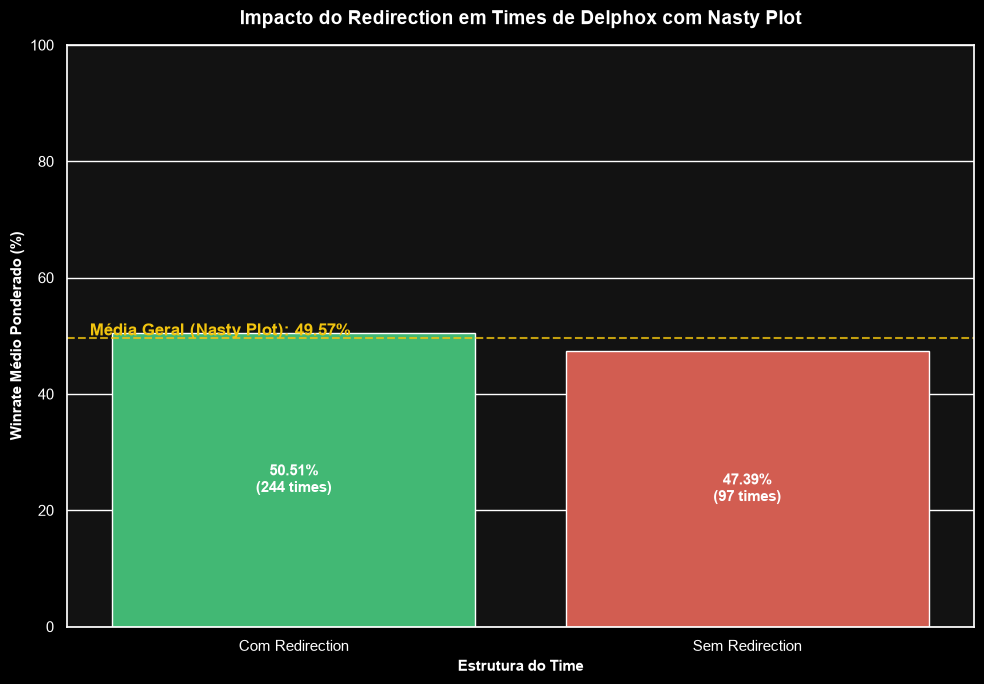

In [32]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def gerar_grafico_nasty_plot_redirection_delphox():
    db = Database()

    query_base = """
    SELECT 
        pt.team_id,
        t.wins,
        t.losses,
        mdata.name AS move_name
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    LEFT JOIN Pokemon_moves pm ON pt.id = pm.idpokemon_team
    LEFT JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    LEFT JOIN Moves_data mdata ON mm.move_api_id = mdata.id
    WHERE pt.team_id IN (
        -- Subquery corrigida com os nomes reais das colunas de mapeamento
        SELECT DISTINCT pt2.team_id
        FROM Pokemon_teams pt2
        JOIN Pokemon_mapping pm2 ON pt2.pokemon_id = pm2.pokemon_scraper_id
        JOIN Pokemon_data pd2 ON pm2.pokemon_api_id = pd2.id
        JOIN Pokemon_moves pm2_m ON pt2.id = pm2_m.idpokemon_team
        JOIN Moves_mapping mm2 ON pm2_m.idmove = mm2.move_scraper_id
        JOIN Moves_data md2 ON mm2.move_api_id = md2.id
        WHERE LOWER(pd2.name) LIKE '%delphox%'
          AND LOWER(REPLACE(md2.name, '-', ' ')) LIKE '%nasty plot%'
    );
    """
    
    print("🔮 Filtrando ecossistema: Analisando suporte de Redirection apenas em times de Delphox com Nasty Plot...")
    with db.connect() as cursor:
        df = pd.read_sql_query(query_base, cursor._connection)

    if df.empty:
        print("❌ Nenhum time de Delphox utilizando Nasty Plot foi encontrado no banco.")
        return

    df['move_clean'] = df['move_name'].fillna('').str.lower().str.replace('-', ' ').str.strip()

    movimentos_redirection = {'follow me', 'rage powder'}
    teams_com_redirection = set(df[df['move_clean'].isin(movimentos_redirection)]['team_id'].unique())

    df_teams_unicos = df.drop_duplicates(subset=['team_id']).copy()
    df_teams_unicos['possui_redirection'] = df_teams_unicos['team_id'].apply(
        lambda x: 'Com Redirection' if x in teams_com_redirection else 'Sem Redirection'
    )

    df_agrupado = df_teams_unicos.groupby('possui_redirection').agg(
        vitorias=('wins', 'sum'),
        derrotas=('losses', 'sum'),
        qtd_times=('team_id', 'count')
    ).reset_index()

    todas_categorias = pd.DataFrame({'possui_redirection': ['Com Redirection', 'Sem Redirection']})
    df_agrupado = pd.merge(todas_categorias, df_agrupado, on='possui_redirection', how='left').fillna(0)

    df_agrupado['winrate'] = 0.0
    mask = (df_agrupado['vitorias'] + df_agrupado['derrotas']) > 0
    df_agrupado.loc[mask, 'winrate'] = (df_agrupado['vitorias'] / (df_agrupado['vitorias'] + df_agrupado['derrotas'])) * 100

    total_v = df_agrupado['vitorias'].sum()
    total_d = df_agrupado['derrotas'].sum()
    media_geral_winrate = (total_v / (total_v + total_d)) * 100 if (total_v + total_d) > 0 else 0

    plt.style.use('dark_background')
    plt.figure(figsize=(10, 7))
    
    sns.set_theme(style="darkgrid", rc={
        "axes.facecolor": "#121212", "figure.facecolor": "#121212",
        "text.color": "white", "axes.labelcolor": "white",
        "xtick.color": "white", "ytick.color": "white"
    })

    cores = ['#2ECC71' if x == 'Com Redirection' else '#E74C3C' for x in df_agrupado['possui_redirection']]
    
    ax = sns.barplot(
        x='possui_redirection', 
        y='winrate', 
        data=df_agrupado, 
        palette=cores, 
        hue='possui_redirection', 
        legend=False
    )
    
    if media_geral_winrate > 0:
        plt.axhline(media_geral_winrate, color='#F1C40F', linestyle='--', linewidth=1.5, alpha=0.8)
        plt.text(-0.45, media_geral_winrate + 0.5, f"Média Geral (Nasty Plot): {media_geral_winrate:.2f}%", color='#F1C40F', weight='bold')

    for p in ax.patches:
        height = p.get_height()
        tipo = df_agrupado['possui_redirection'].iloc[int(p.get_x() + 0.5)]
        qtd = int(df_agrupado[df_agrupado['possui_redirection'] == tipo]['qtd_times'].iloc[0])
        ax.annotate(f"{height:.2f}%\n({qtd} times)", (p.get_x() + p.get_width() / 2., max(height / 2, 5)),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    plt.title("Impacto do Redirection em Times de Delphox com Nasty Plot", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Estrutura do Time", weight='bold', fontsize=11)
    plt.ylabel("Winrate Médio Ponderado (%)", weight='bold', fontsize=11)
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()

gerar_grafico_nasty_plot_redirection_delphox()

🔮 Calculando a distribuição de Usage e Winrate para Delphox (Encore vs Nasty Plot vs Calm Mind)...


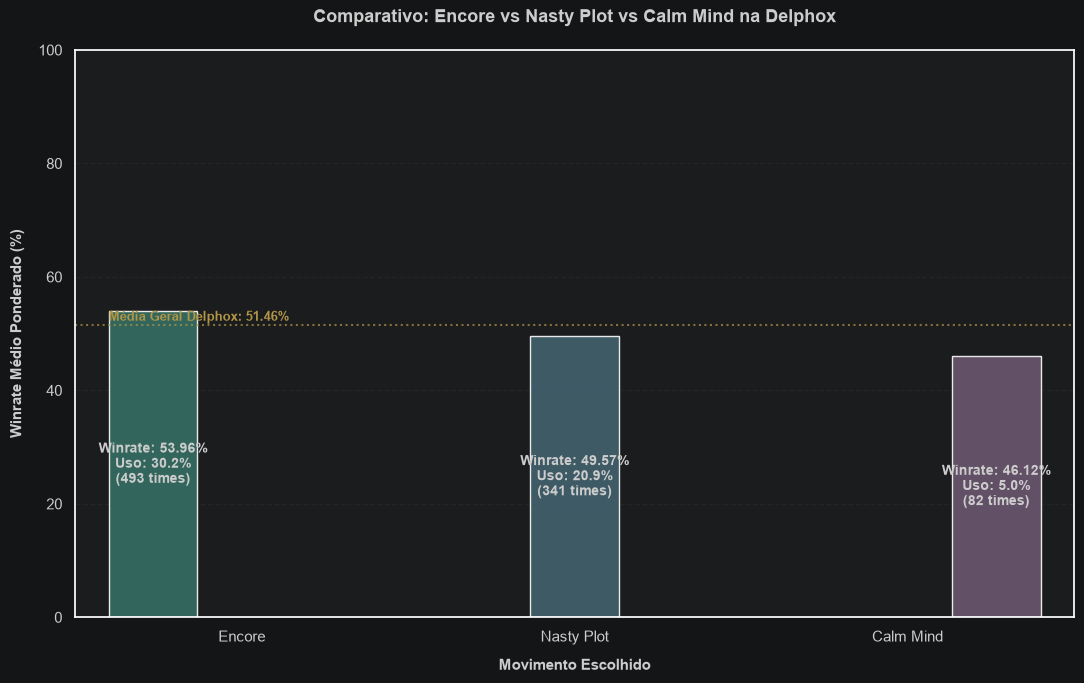

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def analisar_moves_setup_delphox():
    db = Database()

    query_base = """
    SELECT 
        pt.team_id,
        t.wins,
        t.losses,
        pdata.name AS pokemon_name,
        mdata.name AS move_name
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    LEFT JOIN Pokemon_moves pm ON pt.id = pm.idpokemon_team
    LEFT JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    LEFT JOIN Moves_data mdata ON mm.move_api_id = mdata.id
    WHERE pt.team_id IN (
        SELECT DISTINCT pt2.team_id
        FROM Pokemon_teams pt2
        JOIN Pokemon_mapping pm2 ON pt2.pokemon_id = pm2.pokemon_scraper_id
        JOIN Pokemon_data pd2 ON pm2.pokemon_api_id = pd2.id
        WHERE LOWER(pd2.name) LIKE '%delphox%'
    );
    """
    
    print("🔮 Calculando a distribuição de Usage e Winrate para Delphox (Encore vs Nasty Plot vs Calm Mind)...")
    with db.connect() as cursor:
        df = pd.read_sql_query(query_base, cursor._connection)

    if df.empty:
        print("❌ Nenhum dado encontrado para processar.")
        return

    df_delphox = df[df['pokemon_name'].str.lower().str.contains('delphox')].copy()
    df_delphox['move_clean'] = df_delphox['move_name'].fillna('').str.lower().str.replace('-', ' ').str.strip()

    teams_encore = set(df_delphox[df_delphox['move_clean'].str.contains('encore')]['team_id'].unique())
    teams_nasty = set(df_delphox[df_delphox['move_clean'].str.contains('nasty plot')]['team_id'].unique())
    teams_calm = set(df_delphox[df_delphox['move_clean'].str.contains('calm mind')]['team_id'].unique())

    df_teams_unicos = df.drop_duplicates(subset=['team_id']).copy()
    total_geral_times = len(df_teams_unicos)

    registros_filtrados = []
    for _, row in df_teams_unicos.iterrows():
        t_id = row['team_id']
        if t_id in teams_encore:
            novo_reg = row.to_dict()
            novo_reg['cenario'] = 'Encore'
            registros_filtrados.append(novo_reg)
        if t_id in teams_nasty:
            novo_reg = row.to_dict()
            novo_reg['cenario'] = 'Nasty Plot'
            registros_filtrados.append(novo_reg)
        if t_id in teams_calm:
            novo_reg = row.to_dict()
            novo_reg['cenario'] = 'Calm Mind'
            registros_filtrados.append(novo_reg)

    df_final = pd.DataFrame(registros_filtrados)

    if df_final.empty:
        print("❌ Nenhum time utilizando Encore, Nasty Plot ou Calm Mind foi encontrado.")
        return

    df_agrupado = df_final.groupby('cenario').agg(
        vitorias=('wins', 'sum'),
        derrotas=('losses', 'sum'),
        qtd_times=('team_id', 'count')
    ).reset_index()

    df_agrupado['usage_pct'] = (df_agrupado['qtd_times'] / total_geral_times) * 100
    df_agrupado['winrate'] = (df_agrupado['vitorias'] / (df_agrupado['vitorias'] + df_agrupado['derrotas'])) * 100

    ordem_colunas = ['Encore', 'Nasty Plot', 'Calm Mind']
    df_agrupado['cenario'] = pd.Categorical(df_agrupado['cenario'], categories=ordem_colunas, ordered=True)
    df_agrupado = df_agrupado.sort_values('cenario').reset_index(drop=True)

    total_v_global = df_teams_unicos['wins'].sum()
    total_d_global = df_teams_unicos['losses'].sum()
    media_geral_winrate = (total_v_global / (total_v_global + total_d_global)) * 100

    fig, ax = plt.subplots(figsize=(11, 7))
    fig.patch.set_facecolor('#141517')
    ax.set_facecolor('#1b1c1e')

    paleta_cores = {
        'Encore': '#2b786a',
        'Nasty Plot': '#3b6475',
        'Calm Mind': '#6c5274'
    }
    
    cor_texto = "#cccccc"
    cor_grade = "#282a2d"

    sns.barplot(
        x='cenario', 
        y='winrate', 
        data=df_agrupado, 
        palette=paleta_cores, 
        hue='cenario', 
        legend=False,
        alpha=0.9,
        ax=ax
    )
    
    plt.axhline(media_geral_winrate, color='#b09646', linestyle=':', linewidth=1.5, alpha=0.7)
    plt.text(-0.4, media_geral_winrate + 0.8, f"Média Geral Delphox: {media_geral_winrate:.2f}%", color='#b09646', weight='bold', fontsize=9)

    ax.tick_params(colors=cor_texto)
    ax.grid(True, linestyle="--", color=cor_grade, alpha=0.6, axis='y')

    for p in ax.patches:
        height = p.get_height()
        if height <= 0:
            continue
        idx = int(p.get_x() + 0.5)
        if idx >= len(df_agrupado):
            continue
        dado = df_agrupado.iloc[idx]
        
        ax.annotate(f"Winrate: {height:.2f}%\nUso: {dado['usage_pct']:.1f}%\n({int(dado['qtd_times'])} times)", 
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center', fontsize=10, fontweight='bold', color=cor_texto)

    plt.title("Comparativo: Encore vs Nasty Plot vs Calm Mind na Delphox", fontsize=13, weight='bold', pad=20, color=cor_texto)
    plt.xlabel("Movimento Escolhido", weight='bold', fontsize=11, color=cor_texto, labelpad=10)
    plt.ylabel("Winrate Médio Ponderado (%)", weight='bold', fontsize=11, color=cor_texto, labelpad=10)
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()

analisar_moves_setup_delphox()

📊 Buscando dados globais de performance do meta inimigo...


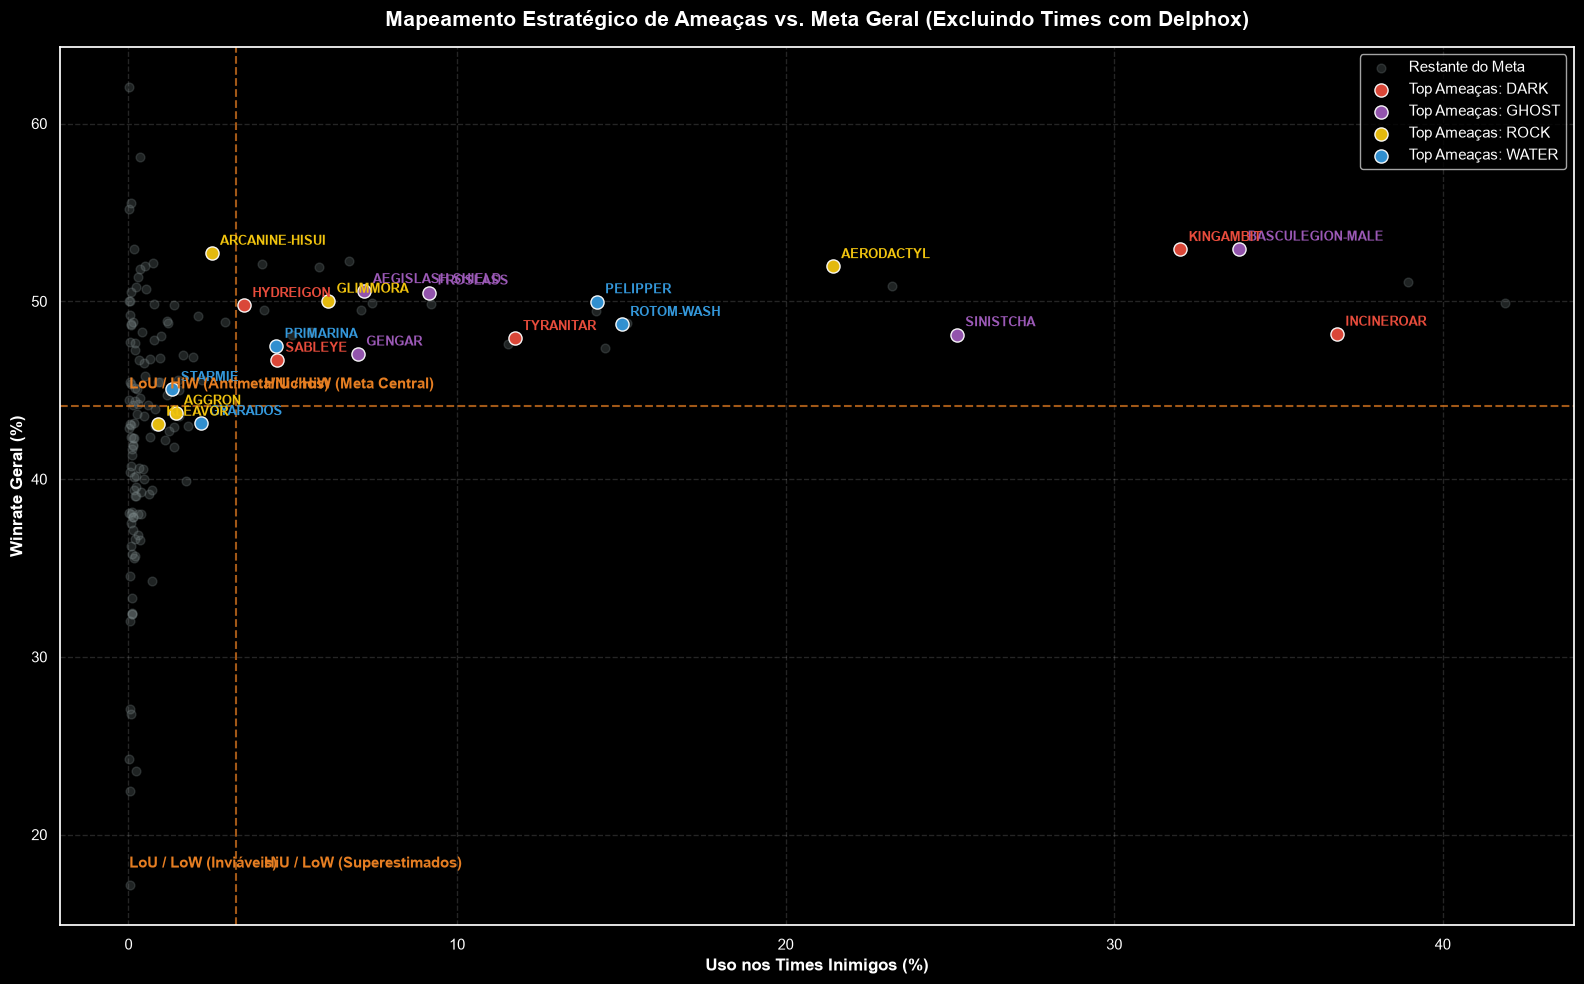

In [15]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def gerar_grafico_quadrantes_ameacas():
    db = Database()
    
    query_times_delphox = """
    SELECT DISTINCT pt.team_id
    FROM Pokemon_teams pt
    JOIN Pokemon_mapping pm ON pt.pokemon_id = pm.pokemon_scraper_id
    JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
    WHERE LOWER(pd.name) LIKE '%delphox%';
    """
    
    with db.connect() as cursor:
        df_delphox_ids = pd.read_sql_query(query_times_delphox, cursor._connection)
        
    delphox_teams_set = set(df_delphox_ids['team_id'].tolist())

    query_meta = """
    SELECT 
        pt.team_id,
        pt.id AS pokemon_team_id,
        pdata.name AS pokemon_name,
        pdata.type1,
        pdata.type2,
        t.wins,
        t.losses
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id;
    """
    
    print("📊 Buscando dados globais de performance do meta inimigo...")
    with db.connect() as cursor:
        df_meta = pd.read_sql_query(query_meta, cursor._connection)

    df_inimigos = df_meta[~df_meta['team_id'].isin(delphox_teams_set)].copy()
    total_teams = df_inimigos['team_id'].nunique()

    df_unique_pokes = df_inimigos.drop_duplicates(subset=['pokemon_team_id'])
    
    df_global = df_unique_pokes.groupby(['pokemon_name', 'type1', 'type2']).agg(
        aparicoes=('team_id', 'count'),
        vitorias=('wins', 'sum'),
        derrotas=('losses', 'sum')
    ).reset_index()

    df_global['usage_percent'] = (df_global['aparicoes'] / total_teams) * 100
    df_global['winrate'] = (df_global['vitorias'] / (df_global['vitorias'] + df_global['derrotas'])) * 100
    
    df_global = df_global[df_global['aparicoes'] >= 5]

    pokemon_tipos_mapeados = {}
    tipos_ordem = ['dark', 'ghost', 'rock', 'water']
    
    for tipo in tipos_ordem:
        df_tipo = df_global[
            ((df_global['type1'].str.lower() == tipo) | (df_global['type2'].str.lower() == tipo)) &
            (~df_global['pokemon_name'].isin(pokemon_tipos_mapeados.keys()))
        ]
        top_5 = df_tipo.sort_values(by='usage_percent', ascending=False).head(5)
        for name in top_5['pokemon_name'].tolist():
            pokemon_tipos_mapeados[name] = tipo

    cores_ameacas = {
        'dark': '#E74C3C',
        'ghost': '#9B59B6',
        'rock': '#F1C40F',
        'water': '#3498DB'
    }

    plt.style.use('dark_background')
    plt.figure(figsize=(16, 10))

    df_neutros = df_global[~df_global['pokemon_name'].isin(pokemon_tipos_mapeados.keys())]
    plt.scatter(
        df_neutros["usage_percent"],
        df_neutros["winrate"],
        alpha=0.25,
        color="#7F8C8D",
        s=40,
        label="Restante do Meta"
    )

    for tipo in tipos_ordem:
        pokes_do_tipo = [p for p, t in pokemon_tipos_mapeados.items() if t == tipo]
        df_ameacas_tipo = df_global[df_global['pokemon_name'].isin(pokes_do_tipo)]
        
        if not df_ameacas_tipo.empty:
            plt.scatter(
                df_ameacas_tipo["usage_percent"],
                df_ameacas_tipo["winrate"],
                alpha=0.95,
                color=cores_ameacas[tipo],
                s=90,
                edgecolors='white',
                linewidths=1,
                label=f"Top Ameaças: {tipo.upper()}"
            )

    for _, row in df_global.iterrows():
        name = row["pokemon_name"]
        if name in pokemon_tipos_mapeados:
            plt.annotate(
                name.upper(),
                (row["usage_percent"], row["winrate"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
                weight='bold',
                color=cores_ameacas[pokemon_tipos_mapeados[name]]
            )

    usage_mean = df_global["usage_percent"].mean()
    winrate_mean = df_global["winrate"].mean()

    plt.axvline(usage_mean, linestyle="--", linewidth=1.5, color="#E67E22", alpha=0.7)
    plt.axhline(winrate_mean, linestyle="--", linewidth=1.5, color="#E67E22", alpha=0.7)

    plt.text(usage_mean + (df_global["usage_percent"].max() * 0.02), winrate_mean + 1, "HiU / HiW (Meta Central)", fontsize=11, weight='bold', color="#E67E22")
    plt.text(df_global["usage_percent"].min(), winrate_mean + 1, "LoU / HiW (Antimeta/Nichos)", fontsize=11, weight='bold', color="#E67E22")
    plt.text(usage_mean + (df_global["usage_percent"].max() * 0.02), df_global["winrate"].min() + 1, "HiU / LoW (Superestimados)", fontsize=11, weight='bold', color="#E67E22")
    plt.text(df_global["usage_percent"].min(), df_global["winrate"].min() + 1, "LoU / LoW (Inviáveis)", fontsize=11, weight='bold', color="#E67E22")

    plt.xlabel("Uso nos Times Inimigos (%)", weight='bold', fontsize=12)
    plt.ylabel("Winrate Geral (%)", weight='bold', fontsize=12)
    plt.title("Mapeamento Estratégico de Ameaças vs. Meta Geral (Excluindo Times com Delphox)", fontsize=15, weight='bold', pad=15)
    plt.grid(True, linestyle="--", alpha=0.15)
    plt.legend(loc="upper right", fontsize=11, framealpha=0.8)

    plt.tight_layout()
    plt.show()

gerar_grafico_quadrantes_ameacas()

In [13]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def analisar_ameacas_contra_delphox():
    db = Database()

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    query_times_delphox = """
    SELECT DISTINCT pt.team_id
    FROM Pokemon_teams pt
    JOIN Pokemon_mapping pm ON pt.pokemon_id = pm.pokemon_scraper_id
    JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
    WHERE LOWER(pd.name) LIKE '%delphox%';
    """
    
    print("🎯 Mapeando ecossistema de times adversários (Sem Delphox)...")
    with db.connect() as cursor:
        df_delphox_ids = pd.read_sql_query(query_times_delphox, cursor._connection)
        
    delphox_teams_set = set(df_delphox_ids['team_id'].tolist())

    query_meta_geral = """
    SELECT 
        pt.team_id,
        pt.id AS pokemon_team_id,
        pdata.name AS pokemon_name,
        pdata.type1,
        pdata.type2,
        i.name AS item_name,
        t.wins,
        t.losses
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    JOIN Items i ON pt.item_id = i.id;
    """
    
    with db.connect() as cursor:
        df_meta = pd.read_sql_query(query_meta_geral, cursor._connection)

    df_inimigos_completo = df_meta[~df_meta['team_id'].isin(delphox_teams_set)].copy()
    
    if df_inimigos_completo.empty:
        print("❌ Nenhum time adversário encontrado na base de dados.")
        return

    query_moves_geral = """
    SELECT 
        pm.idpokemon_team,
        mdata.name AS move_name,
        mdata.damage_class
    FROM Pokemon_moves pm
    JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    JOIN Moves_data mdata ON mm.move_api_id = mdata.id;
    """
    
    with db.connect() as cursor:
        df_moves_meta = pd.read_sql_query(query_moves_geral, cursor._connection)

    total_inimigo_teams = df_inimigos_completo['team_id'].nunique()
    
    tipos_alvo = ['dark', 'ghost', 'rock', 'water']
    pokemon_ja_processados = set()
    
    output_lines = []
    output_lines.append("==================================================================")
    output_lines.append("RAIO-X DAS MAIORES AMEAÇAS AO META DA DELPHOX (DADOS INIMIGOS)")
    output_lines.append("==================================================================")

    for tipo in tipos_alvo:
        output_lines.append(f"\n💀 TIPO PROEMINENTE: {tipo.upper()}")
        output_lines.append("------------------------------------------------------------------")
        
        df_tipo = df_inimigos_completo[
            (df_inimigos_completo['type1'].str.lower() == tipo) | 
            (df_inimigos_completo['type2'].str.lower() == tipo)
        ]
        
        df_tipo_filtrado = df_tipo[~df_tipo['pokemon_name'].isin(pokemon_ja_processados)]
        
        if df_tipo_filtrado.empty:
            output_lines.append("  Nenhum Pokémon novo deste tipo encontrado nos times inimigos.")
            continue
            
        df_unique_pokes = df_tipo_filtrado.drop_duplicates(subset=['pokemon_team_id'])
        
        agg_pokes = df_unique_pokes.groupby('pokemon_name').agg(
            aparicoes=('team_id', 'count'),
            vitorias=('wins', 'sum'),
            derrotas=('losses', 'sum')
        ).reset_index()
        
        agg_pokes['presenca_pct'] = (agg_pokes['aparicoes'] / total_inimigo_teams) * 100
        agg_pokes['winrate_pct'] = (agg_pokes['vitorias'] / (agg_pokes['vitorias'] + agg_pokes['derrotas'])) * 100
        top_5_pokes = agg_pokes.sort_values(by='presenca_pct', ascending=False).head(5)
        
        for _, poke_row in top_5_pokes.iterrows():
            name = poke_row['pokemon_name']
            pres = poke_row['presenca_pct']
            wr = poke_row['winrate_pct']
            
            pokemon_ja_processados.add(name)
            
            output_lines.append(f"\n➔ Pokémon: {name.upper()} | Presença no Meta Inimigo: {pres:.2f}% | Winrate Geral: {wr:.2f}%")
            
            df_especifico = df_tipo_filtrado[df_tipo_filtrado['pokemon_name'] == name]
            df_unique_items = df_especifico.drop_duplicates(subset=['pokemon_team_id'])
            
            top_items = df_unique_items['item_name'].value_counts().head(3).reset_index()
            top_items.columns = ['item_name', 'count']
            
            items_str = ", ".join([f"{r['item_name']} ({int((r['count']/len(df_unique_items))*100)}%)" for _, r in top_items.iterrows()])
            output_lines.append(f"   Itens comuns: {items_str}")
            
            poke_team_ids = df_especifico['pokemon_team_id'].unique()
            df_poke_moves = df_moves_meta[df_moves_meta['idpokemon_team'].isin(poke_team_ids)]
            
            if not df_poke_moves.empty:
                top_moves = df_poke_moves['move_name'].value_counts().head(5).reset_index()
                top_moves.columns = ['move_name', 'count']
                
                moves_list = []
                for _, m_row in top_moves.iterrows():
                    m_name = m_row['move_name']
                    m_class = df_poke_moves[df_poke_moves['move_name'] == m_name]['damage_class'].iloc[0]
                    moves_list.append(f"{m_name} [{m_class}]")
                
                output_lines.append(f"   Top Moves:    {', '.join(moves_list)}")

    print("\n".join(output_lines))

analisar_ameacas_contra_delphox()

🎯 Mapeando ecossistema de times adversários (Sem Delphox)...
RAIO-X DAS MAIORES AMEAÇAS AO META DA DELPHOX (DADOS INIMIGOS)

💀 TIPO PROEMINENTE: DARK
------------------------------------------------------------------

➔ Pokémon: INCINEROAR | Presença no Meta Inimigo: 36.79% | Winrate Geral: 48.16%
   Itens comuns: Sitrus Berry (50%), Chople Berry (22%), Shuca Berry (9%)
   Top Moves:    fake-out [physical], parting-shot [status], flare-blitz [physical], throat-chop [physical], darkest-lariat [physical]

➔ Pokémon: KINGAMBIT | Presença no Meta Inimigo: 32.01% | Winrate Geral: 52.92%
   Itens comuns: Chople Berry (47%), Black Glasses (44%), Focus Sash (3%)
   Top Moves:    sucker-punch [physical], kowtow-cleave [physical], protect [status], iron-head [physical], low-kick [physical]

➔ Pokémon: TYRANITAR | Presença no Meta Inimigo: 11.76% | Winrate Geral: 47.91%
   Itens comuns: Tyranitarite (74%), Focus Sash (7%), Choice Scarf (5%)
   Top Moves:    rock-slide [physical], protect [status]

Conectando ao banco e analisando co-Megas do Mega Delphox...


C:\Users\User\AppData\Local\Temp\ipykernel_12532\2769689897.py:57: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_local = pd.read_sql_query(query, cursor._connection)



📊 Gráfico de análise de co-megas salvo com sucesso em: ../sql/delphox_co_megas_analysis.png


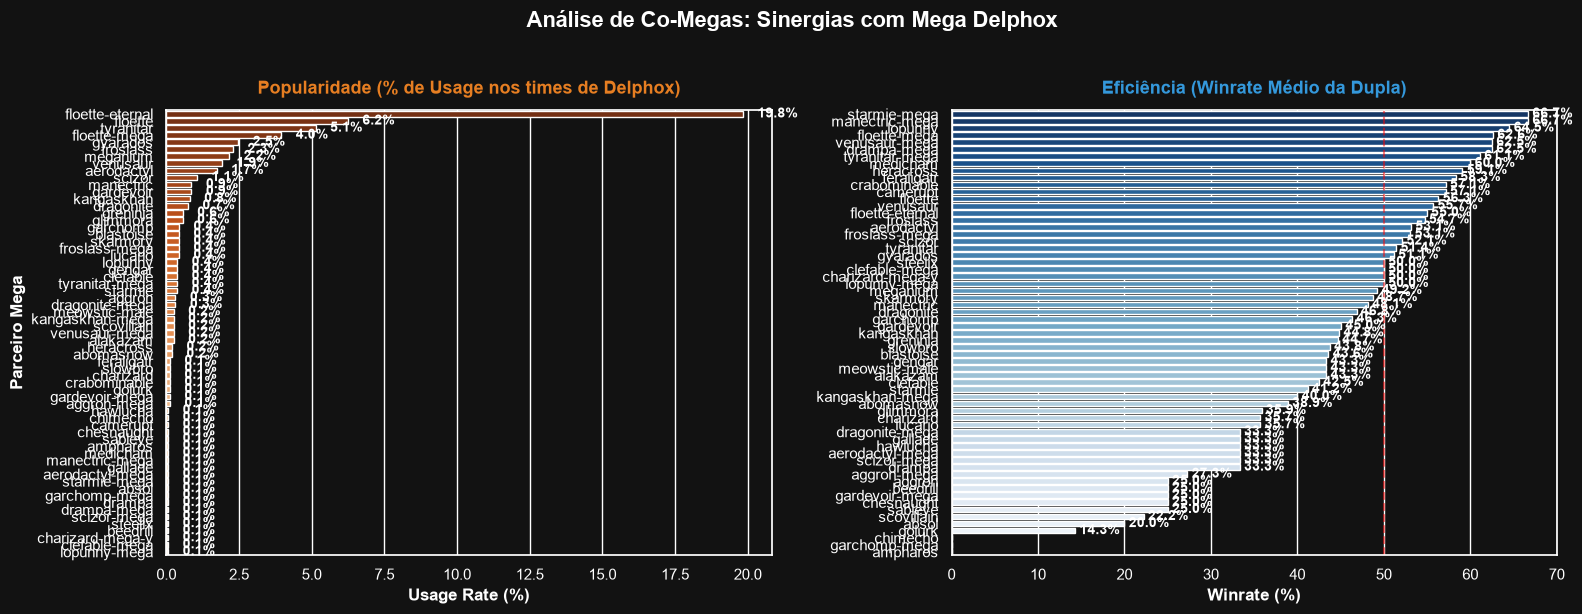

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imports.database import Database

def analisar_co_megas_delphox():
    db = Database()
    
    query = """
    WITH DelphoxTeams AS (
        -- Isola apenas os times que possuem o Mega Delphox de fato
        SELECT DISTINCT pt.team_id
        FROM Pokemon_teams pt
        JOIN Items i ON pt.item_id = i.id
        JOIN Pokemon_mapping pm ON pt.pokemon_id = pm.pokemon_scraper_id
        JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
        WHERE LOWER(pd.name) LIKE '%delphox%' 
          AND LOWER(i.name) LIKE '%delphoxite%'
    ),
    OtherMegas AS (
        -- Busca a OUTRA mega que está no mesmo time
        SELECT 
            dt.team_id,
            t.wins,
            t.losses,
            pd.name AS mega_name
        FROM DelphoxTeams dt
        JOIN Teams t ON dt.team_id = t.id
        JOIN Pokemon_teams pt ON dt.team_id = pt.team_id
        JOIN Items i ON pt.item_id = i.id
        JOIN Pokemon_mapping pm ON pt.pokemon_id = pm.pokemon_scraper_id
        JOIN Pokemon_data pd ON pm.pokemon_api_id = pd.id
        WHERE (LOWER(i.name) LIKE '%ite' 
           OR LOWER(i.name) LIKE '%ite x' 
           OR LOWER(i.name) LIKE '%ite y')
          AND LOWER(pd.name) NOT LIKE '%delphox%' -- Exclui o próprio Delphox da contagem
    ),
    TotalDelphox AS (
        -- Conta o total de times de Mega Delphox para calcular a % de Usage corretamente
        SELECT COUNT(*) AS total_teams FROM DelphoxTeams
    )
    SELECT 
        om.mega_name AS mega,
        COUNT(om.team_id) AS qtd_times,
        ROUND(100.0 * COUNT(om.team_id) / (SELECT total_teams FROM TotalDelphox), 2) AS usage_rate,
        ROUND(100.0 * SUM(om.wins) / NULLIF(SUM(om.wins) + SUM(om.losses), 0), 2) AS winrate
    FROM OtherMegas om
    GROUP BY om.mega_name
    ORDER BY qtd_times DESC;
    """
    
    print("Conectando ao banco e analisando co-Megas do Mega Delphox...")
    with db.connect() as cursor:
        df_local = pd.read_sql_query(query, cursor._connection)
        
    if df_local.empty:
        print("❌ Nenhuma outra Mega encontrada nos times de Mega Delphox.")
        return None
        
    return df_local

df = analisar_co_megas_delphox()

if df is not None and not df.empty:
    plt.style.use('dark_background')
    sns.set_theme(style="darkgrid", rc={
        "axes.facecolor": "#121212", 
        "figure.facecolor": "#121212",
        "text.color": "white",
        "axes.labelcolor": "white",
        "xtick.color": "white",
        "ytick.color": "white"
    })

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Análise de Co-Megas: Sinergias com Mega Delphox', fontsize=16, fontweight='bold', color='#FFFFFF', y=1.02)

    sns.barplot(x='usage_rate', y='mega', data=df, ax=axes[0], palette='Oranges_r', hue='mega', legend=False)
    axes[0].set_title('Popularidade (% de Usage nos times de Delphox)', fontsize=13, color='#E67E22', weight='bold', pad=12)
    axes[0].set_xlabel('Usage Rate (%)', weight='bold')
    axes[0].set_ylabel('Parceiro Mega', weight='bold')
    
    for p in axes[0].patches:
        width = p.get_width()
        if width > 0:
            axes[0].annotate(f"{width:.1f}%", (width + 0.5, p.get_y() + p.get_height()/2.),
                        ha='left', va='center', fontsize=10, fontweight='bold', color='white')

    df_win = df.sort_values(by='winrate', ascending=False)
    sns.barplot(x='winrate', y='mega', data=df_win, ax=axes[1], palette='Blues_r', hue='mega', legend=False)
    axes[1].set_title('Eficiência (Winrate Médio da Dupla)', fontsize=13, color='#3498DB', weight='bold', pad=12)
    axes[1].set_xlabel('Winrate (%)', weight='bold')
    axes[1].set_ylabel('')
    
    axes[1].axvline(50, color='red', linestyle='--', alpha=0.5)

    for p in axes[1].patches:
        width = p.get_width()
        if width > 0:
            axes[1].annotate(f"{width:.1f}%", (width + 0.5, p.get_y() + p.get_height()/2.),
                        ha='left', va='center', fontsize=10, fontweight='bold', color='white')

    plt.tight_layout()
    
    save_path = '../sql/delphox_co_megas_analysis.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n📊 Gráfico de análise de co-megas salvo com sucesso em: {save_path}")
    plt.show()

Buscando dados das táticas de times no banco...


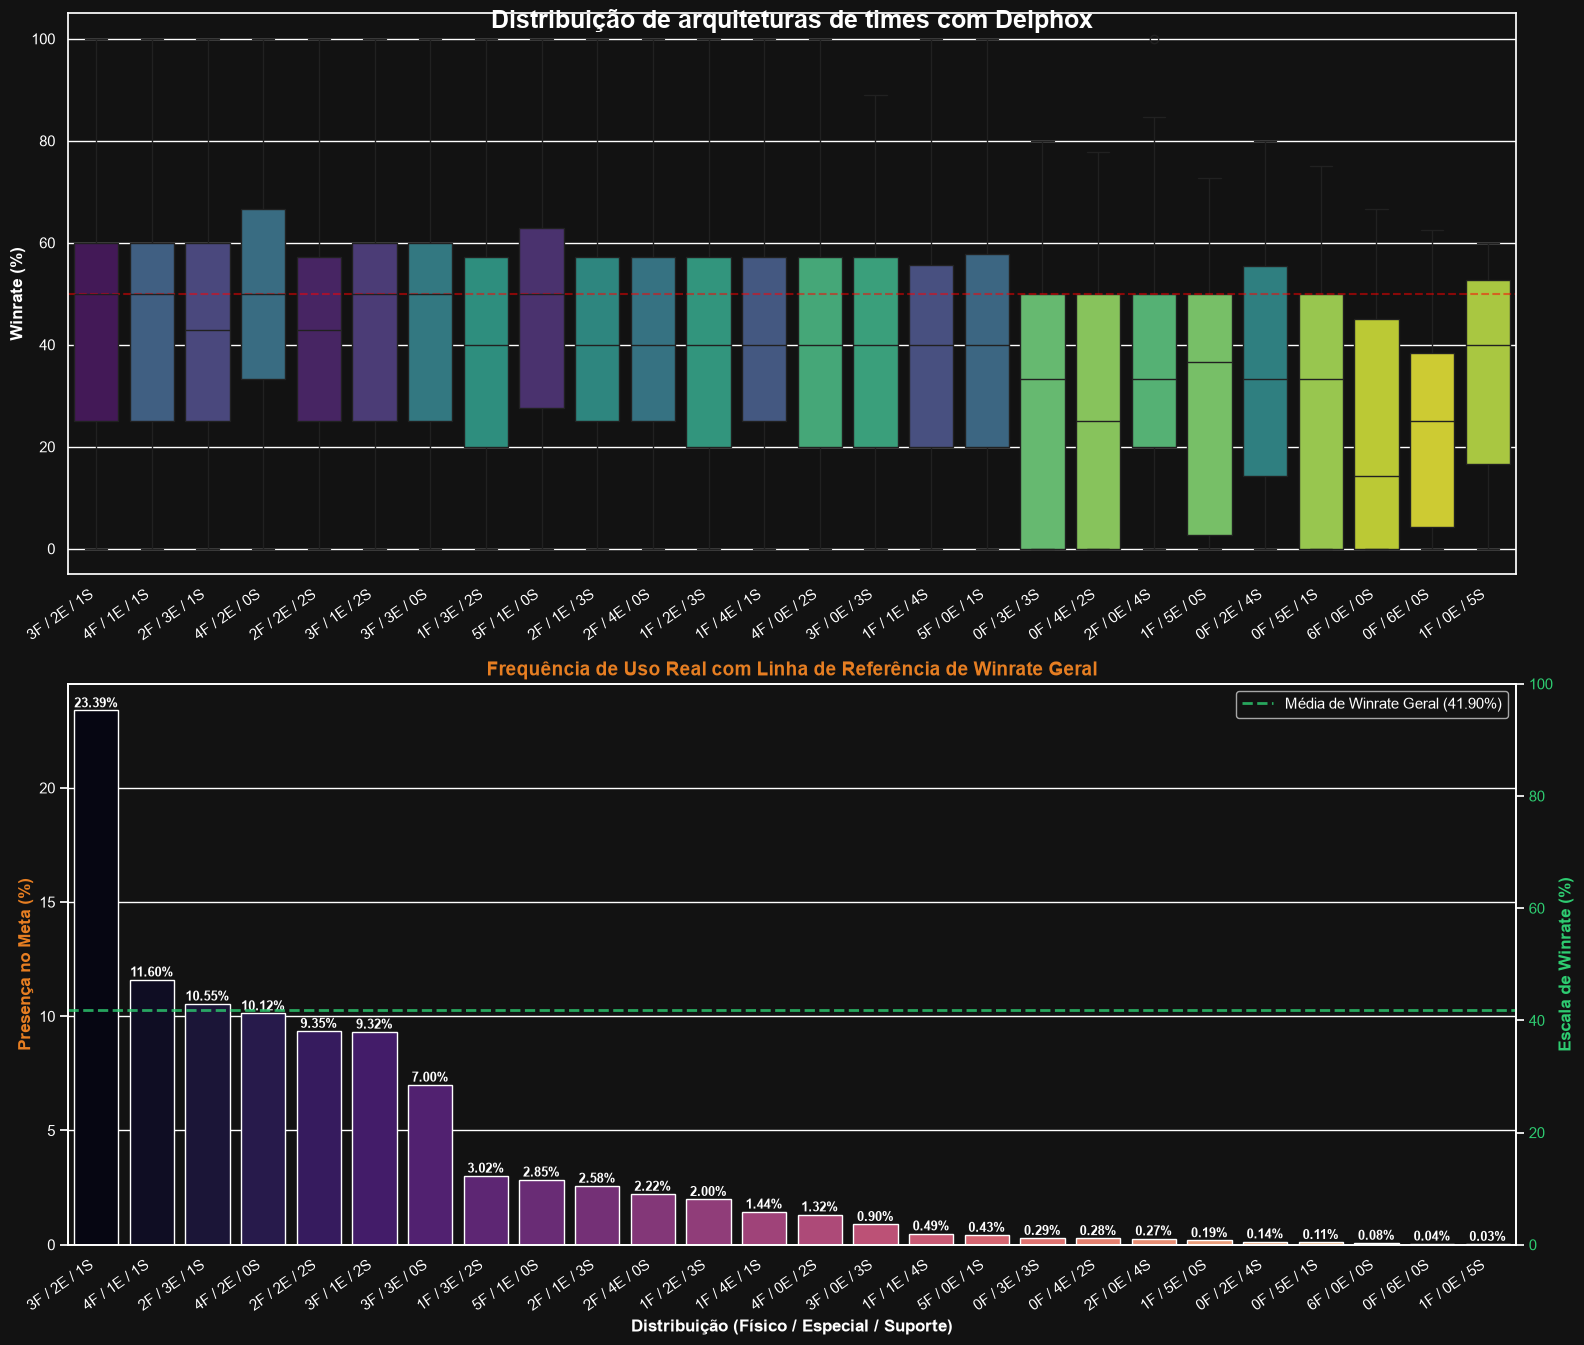

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def analisar_arqueticos_de_times_correto():
    db = Database()
    
    query = """
    WITH ClassificacaoMoves AS (
        SELECT 
            pt.team_id,
            pt.id AS pokemon_team_id,
            md.damage_class
        FROM Pokemon_moves pm
        JOIN Pokemon_teams pt ON pm.idpokemon_team = pt.id
        JOIN Moves m ON pm.idmove = m.id
        JOIN Moves_mapping mm ON m.id = mm.move_scraper_id
        JOIN Moves_data md ON mm.move_api_id = md.id
        WHERE LOWER(md.name) NOT LIKE '%protect%'
          AND LOWER(md.name) NOT LIKE '%detect%'
          AND LOWER(md.name) NOT LIKE '%spiky shield%'
          AND LOWER(md.name) NOT LIKE '%baneful bunker%'
          AND LOWER(md.name) NOT LIKE '%kings shield%'
    ),
    ContagemPokemon AS (
        SELECT 
            team_id,
            pokemon_team_id,
            SUM(CASE WHEN LOWER(damage_class) = 'physical' THEN 1 ELSE 0 END) AS qtd_phys,
            SUM(CASE WHEN LOWER(damage_class) = 'special' THEN 1 ELSE 0 END) AS qtd_spec,
            SUM(CASE WHEN LOWER(damage_class) = 'status' THEN 1 ELSE 0 END) AS qtd_status
        FROM ClassificacaoMoves
        GROUP BY team_id, pokemon_team_id
    ),
    PapelPokemon AS (
        SELECT 
            team_id,
            CASE 
                WHEN qtd_status >= qtd_phys AND qtd_status >= qtd_spec THEN 'Support'
                WHEN qtd_phys >= qtd_spec THEN 'Physical'
                ELSE 'Special'
            END AS papel
        FROM ContagemPokemon
    ),
    DistribuicaoTime AS (
        SELECT 
            team_id,
            SUM(CASE WHEN papel = 'Physical' THEN 1 ELSE 0 END) AS phys_slots,
            SUM(CASE WHEN papel = 'Special' THEN 1 ELSE 0 END) AS spec_slots,
            SUM(CASE WHEN papel = 'Support' THEN 1 ELSE 0 END) AS supp_slots
        FROM PapelPokemon
        GROUP BY team_id
    )
    SELECT 
        dt.team_id,
        t.wins,
        t.losses,
        CONCAT(dt.phys_slots, 'F / ', dt.spec_slots, 'E / ', dt.supp_slots, 'S') AS distribuicao,
        ROUND(100.0 * t.wins / NULLIF(t.wins + t.losses, 0), 2) AS winrate
    FROM DistribuicaoTime dt
    JOIN Teams t ON dt.team_id = t.id
    WHERE (t.wins + t.losses) > 0;
    """
    
    print("Buscando dados das táticas de times no banco...")
    with db.connect() as cursor:
        conexao = cursor._connection
        df_local = pd.read_sql_query(query, conexao)
        
    return df_local

df_teams = analisar_arqueticos_de_times_correto()

if df_teams is not None and not df_teams.empty:
    def extrair_e_somar_slots(dist_string):
        try:
            numeros = [int(s) for s in dist_string.replace('F', '').replace('E', '').replace('S', '').split('/')]
            return sum(numeros)
        except:
            return 0

    df_teams['total_pokemon'] = df_teams['distribuicao'].apply(extrair_e_somar_slots)
    df_perfeitos = df_teams[df_teams['total_pokemon'] == 6].copy()
    
    contagem_dist = df_perfeitos['distribuicao'].value_counts()
    dist_validas = contagem_dist[contagem_dist >= 5].index
    df_filtrado = df_perfeitos[df_perfeitos['distribuicao'].isin(dist_validas)]
    ordem_popularidade = df_filtrado['distribuicao'].value_counts().index
    
    media_winrate_geral = df_filtrado['winrate'].mean()

    plt.style.use('dark_background')
    sns.set_theme(style="darkgrid", rc={
        "axes.facecolor": "#121212", "figure.facecolor": "#121212",
        "text.color": "white", "axes.labelcolor": "white",
        "xtick.color": "white", "ytick.color": "white"
    })

    fig, axes = plt.subplots(2, 1, figsize=(16, 14))
    fig.suptitle('Distribuição de arquiteturas de times com Delphox', fontsize=18, fontweight='bold', y=0.96)

    sns.boxplot(x='distribuicao', y='winrate', data=df_filtrado, order=ordem_popularidade, ax=axes[0], palette='viridis', hue='distribuicao', legend=False)
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Winrate (%)', weight='bold')
    axes[0].axhline(50, color='red', linestyle='--', alpha=0.5)
    axes[0].set_xticklabels(ordem_popularidade, rotation=35, ha='right')

    df_usage = df_filtrado['distribuicao'].value_counts(normalize=True).reset_index()
    df_usage.columns = ['distribuicao', 'usage_pct']
    df_usage['usage_pct'] *= 100

    sns.barplot(x='distribuicao', y='usage_pct', data=df_usage, order=ordem_popularidade, ax=axes[1], palette='magma', hue='distribuicao', legend=False)
    axes[1].set_title('Frequência de Uso Real com Linha de Referência de Winrate Geral', fontsize=14, color='#E67E22', weight='bold')
    axes[1].set_xlabel('Distribuição (Físico / Especial / Suporte)', weight='bold')
    axes[1].set_ylabel('Presença no Meta (%)', color='#E67E22', weight='bold')
    axes[1].set_xticklabels(ordem_popularidade, rotation=35, ha='right')

    ax2 = axes[1].twinx()
    ax2.set_ylabel('Escala de Winrate (%)', color='#2ECC71', weight='bold')
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis='y', labelcolor='#2ECC71')
    ax2.grid(False)

    ax2.axhline(media_winrate_geral, color='#2ECC71', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Média de Winrate Geral ({media_winrate_geral:.2f}%)')
    
    ax2.legend(loc='upper right')

    for p in axes[1].patches:
        height = p.get_height()
        if height > 0:
            axes[1].annotate(f"{height:.2f}%", (p.get_x() + p.get_width() / 2., height + 0.3),
                        ha='center', va='center', fontsize=9, fontweight='bold', color='white')

    plt.tight_layout()
    plt.show()

🔮 Mapeando todas as combinações de quintetos usadas com a Delphox...


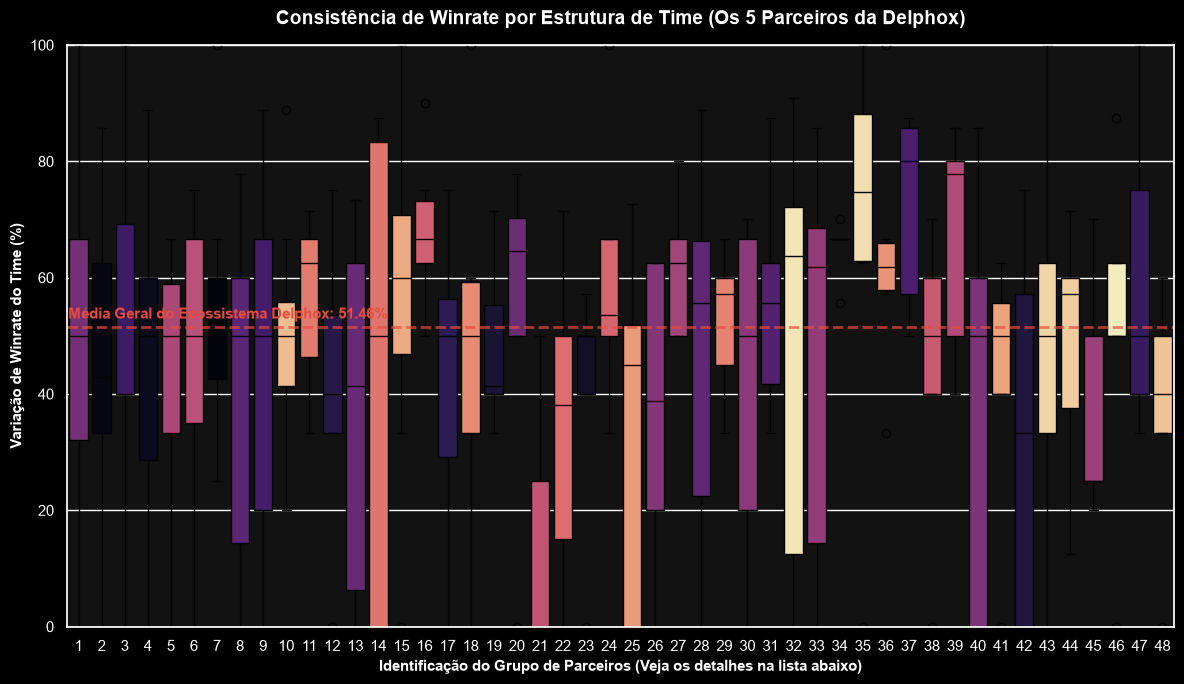


🗺️ COMPOSIÇÕES DETALHADAS:
📋 1 [Uso: 4.4% | WR: 56.0%]
   ↳ BASCULEGION-MALE | CLEFABLE | DRAGONITE | KINGAMBIT | SNEASLER

📋 2 [Uso: 2.6% | WR: 48.7%]
   ↳ FLOETTE-ETERNAL | INCINEROAR | MAUSHOLD-FAMILY-OF-FOUR | SINISTCHA | VIVILLON

📋 3 [Uso: 2.6% | WR: 57.2%]
   ↳ BASCULEGION-MALE | CLEFABLE | GARCHOMP | KINGAMBIT | SNEASLER

📋 4 [Uso: 2.3% | WR: 50.3%]
   ↳ BASCULEGION-MALE | FLOETTE-ETERNAL | INCINEROAR | SINISTCHA | SNEASLER

📋 5 [Uso: 1.8% | WR: 49.7%]
   ↳ AERODACTYL | GARCHOMP | KINGAMBIT | SNEASLER | TSAREENA

📋 6 [Uso: 1.8% | WR: 54.7%]
   ↳ AERODACTYL | GARCHOMP | KINGAMBIT | ROTOM-WASH | SNEASLER

📋 7 [Uso: 1.1% | WR: 52.3%]
   ↳ FLOETTE-ETERNAL | INCINEROAR | KINGAMBIT | SINISTCHA | SNEASLER

📋 8 [Uso: 1.0% | WR: 48.9%]
   ↳ AERODACTYL | BASCULEGION-MALE | GARCHOMP | KINGAMBIT | SNEASLER

📋 9 [Uso: 1.0% | WR: 54.8%]
   ↳ CLEFABLE | GARCHOMP | GYARADOS | KINGAMBIT | SNEASLER

📋 10 [Uso: 0.9% | WR: 52.0%]
   ↳ AERODACTYL | FLOETTE | GARCHOMP | INCINEROAR | MAUSHOLD-FAMILY

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def gerar_boxplot_times_completos_delphox():
    db = Database()
    
    query = """
    SELECT 
        pt.team_id,
        pdata.name AS pokemon_name,
        t.wins,
        t.losses,
        ROUND(100.0 * t.wins / NULLIF(t.wins + t.losses, 0), 2) AS winrate
    FROM Pokemon_teams pt
    JOIN Teams t ON pt.team_id = t.id
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    WHERE pt.team_id IN (
        SELECT DISTINCT pt2.team_id
        FROM Pokemon_teams pt2
        JOIN Pokemon_mapping pm2 ON pt2.pokemon_id = pm2.pokemon_scraper_id
        JOIN Pokemon_data pd2 ON pm2.pokemon_api_id = pd2.id
        WHERE LOWER(pd2.name) LIKE '%delphox%'
    );
    """
    
    print("🔮 Mapeando todas as combinações de quintetos usadas com a Delphox...")
    with db.connect() as cursor:
        df = pd.read_sql_query(query, cursor._connection)
        
    if df.empty:
        print("❌ Nenhum dado encontrado para processar.")
        return

    df_contagem = df.groupby('team_id').size().reset_index(name='qtd')
    teams_6_pokes = df_contagem[df_contagem['qtd'] == 6]['team_id'].tolist()
    df_filtrado = df[df['team_id'].isin(teams_6_pokes)].copy()
    
    total_times_delphox = len(teams_6_pokes)

    df_parceiros = df_filtrado[~df_filtrado['pokemon_name'].str.lower().str.contains('delphox')].copy()
    
    quintetos_list = []
    for t_id, group in df_parceiros.groupby('team_id'):
        nomes_parceiros = sorted(group['pokemon_name'].str.upper().tolist())
        string_quinteto = " | ".join(nomes_parceiros)
        
        winrate = group['winrate'].iloc[0]
        wins = group['wins'].iloc[0]
        losses = group['losses'].iloc[0]
        
        quintetos_list.append({
            'team_id': t_id,
            'quinteto': string_quinteto,
            'winrate': winrate,
            'wins': wins,
            'losses': losses
        })
        
    df_quintetos = pd.DataFrame(quintetos_list)
    
    contagem_quintetos = df_quintetos['quinteto'].value_counts()
    quintetos_populares = contagem_quintetos[contagem_quintetos >= 5].index.tolist()
    
    if not quintetos_populares:
        print("⚠️ Nenhuma combinação idêntica de 5 Pokémon apareceu 5 ou mais vezes. Reduzindo limite para 2...")
        quintetos_populares = contagem_quintetos[contagem_quintetos >= 2].index.tolist()
        
    if not quintetos_populares:
        print("❌ As combinações de times são muito dispersas para gerar o Boxplot.")
        return
        
    df_plot = df_quintetos[df_quintetos['quinteto'].isin(quintetos_populares)].copy()
    
    df_info_labels = df_plot.groupby('quinteto').agg(
        qtd_times=('team_id', 'count'),
        v_tot=('wins', 'sum'),
        d_tot=('losses', 'sum')
    ).reset_index()
    
    df_info_labels['usage_pct'] = (df_info_labels['qtd_times'] / total_times_delphox) * 100
    df_info_labels['wr_ponderado'] = (df_info_labels['v_tot'] / (df_info_labels['v_tot'] + df_info_labels['d_tot'])) * 100
    df_info_labels = df_info_labels.sort_values(by='usage_pct', ascending=False)
    
    mapa_indices = {}
    legenda_lista = []
    
    for idx, row in enumerate(df_info_labels.iterrows(), start=1):
        quinteto_str = row[1]['quinteto']
        usage = row[1]['usage_pct']
        wr = row[1]['wr_ponderado']
        
        label_curto = f"{idx}"
        mapa_indices[quinteto_str] = label_curto
        
        legenda_lista.append(f"📋 {label_curto} [Uso: {usage:.1f}% | WR: {wr:.1f}%]\n   ↳ {quinteto_str}")
        
    df_plot['Quinteto_Curto'] = df_plot['quinteto'].map(mapa_indices)
    ordem_eixo_x = [mapa_indices[q] for q in df_info_labels['quinteto'].tolist()]

    plt.style.use('dark_background')
    plt.figure(figsize=(12, 7))
    
    sns.set_theme(style="darkgrid", rc={
        "axes.facecolor": "#121212", "figure.facecolor": "#121212",
        "text.color": "white", "axes.labelcolor": "white",
        "xtick.color": "white", "ytick.color": "white"
    })

    sns.boxplot(
        x='Quinteto_Curto', 
        y='winrate', 
        data=df_plot, 
        order=ordem_eixo_x, 
        palette='magma', 
        hue='Quinteto_Curto', 
        legend=False
    )
    
    media_delphox_global = (df_quintetos['wins'].sum() / (df_quintetos['wins'].sum() + df_quintetos['losses'].sum())) * 100
    plt.axhline(media_delphox_global, color='#E74C3C', linestyle='--', linewidth=2, alpha=0.7)
    plt.text(-0.45, media_delphox_global + 1.5, f"Média Geral do Ecossistema Delphox: {media_delphox_global:.2f}%", color='#E74C3C', weight='bold', fontsize=11)

    plt.title("Consistência de Winrate por Estrutura de Time (Os 5 Parceiros da Delphox)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Identificação do Grupo de Parceiros (Veja os detalhes na lista abaixo)", weight='bold', fontsize=11)
    plt.ylabel("Variação de Winrate do Time (%)", weight='bold', fontsize=11)
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show() 

    print("\n🗺️ COMPOSIÇÕES DETALHADAS:")
    print("==========================================================================================")
    print("\n\n".join(legenda_lista))
    print("==========================================================================================")

gerar_boxplot_times_completos_delphox()

In [23]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def analisar_build_time_especifico_delphox():
    db = Database()
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)

    query_equipe = """
    SELECT 
        pt.team_id,
        pdata.name AS pokemon_name
    FROM Pokemon_teams pt
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    WHERE pt.team_id IN (
        SELECT DISTINCT pt2.team_id
        FROM Pokemon_teams pt2
        JOIN Pokemon_mapping pm2 ON pt2.pokemon_id = pm2.pokemon_scraper_id
        JOIN Pokemon_data pd2 ON pm2.pokemon_api_id = pd2.id
        WHERE LOWER(pd2.name) LIKE '%delphox%'
    );
    """
    
    print("🔍 Localizando registros do time alvo com Delphox...")
    with db.connect() as cursor:
        df_all = pd.read_sql_query(query_equipe, cursor._connection)
        
    if df_all.empty:
        print("❌ Nenhum dado encontrado.")
        return

    parceiros_alvo = {'basculegion-male', 'clefable', 'dragonite', 'kingambit', 'sneasler'}
    
    times_validos_ids = []
    for t_id, group in df_all.groupby('team_id'):
        nomes_no_time = set(group['pokemon_name'].str.lower().tolist())
        if parceiros_alvo.issubset(nomes_no_time):
            times_validos_ids.append(t_id)
            
    total_times_alvo = len(times_validos_ids)
    
    if total_times_alvo == 0:
        print("❌ Não foram encontrados times contendo exatamente esses 5 parceiros juntos com a Delphox.")
        return
        
    print(f"✅ Encontrados {total_times_alvo} times com essa composição exata! Extraindo detalhes das builds...\n")

    where_clause = f"WHERE pt.team_id = {times_validos_ids[0]}" if total_times_alvo == 1 else f"WHERE pt.team_id IN {tuple(times_validos_ids)}"

    query_detalhes = f"""
    SELECT 
        pt.id AS pokemon_team_id,
        pdata.name AS pokemon_name,
        i.name AS item_name,
        mdata.name AS move_name,
        mdata.damage_class
    FROM Pokemon_teams pt
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    JOIN Items i ON pt.item_id = i.id
    LEFT JOIN Pokemon_moves pm ON pt.id = pm.idpokemon_team
    LEFT JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    LEFT JOIN Moves_data mdata ON mm.move_api_id = mdata.id
    {where_clause}
      AND LOWER(pdata.name) IN ('basculegion-male', 'clefable', 'dragonite', 'kingambit', 'sneasler');
    """

    with db.connect() as cursor:
        df_detalhes = pd.read_sql_query(query_detalhes, cursor._connection)

    output_lines = []
    output_lines.append("==========================================================================================")
    output_lines.append(f"RAIO-X DE BUILDS: BASCULEGION-MALE | CLEFABLE | DRAGONITE | KINGAMBIT | SNEASLER")
    output_lines.append(f"Foco: Apenas em times acompanhando Delphox (Amostra: {total_times_alvo} times)")
    output_lines.append("==========================================================================================")

    for poke in sorted(list(parceiros_alvo)):
        df_poke = df_detalhes[df_detalhes['pokemon_name'].str.lower() == poke]
        if df_poke.empty:
            continue
            
        output_lines.append(f"\n➔ POKÉMON: {poke.upper()}")
        output_lines.append("------------------------------------------------------------------------------------------")
        
        df_items_unicos = df_poke.drop_duplicates(subset=['pokemon_team_id'])
        top_items = df_items_unicos['item_name'].value_counts().reset_index()
        top_items.columns = ['item_name', 'count']
        
        output_lines.append("  📦 DISTRIBUIÇÃO DE ITENS:")
        for _, row in top_items.iterrows():
            pct_item = (row['count'] / total_times_alvo) * 100
            output_lines.append(f"     • {row['item_name']:<22} -> {pct_item:.1f}% de uso")
            
        top_moves = df_poke['move_name'].value_counts().reset_index()
        top_moves.columns = ['move_name', 'count']
        
        output_lines.append("\n  ⚔️ DISTRIBUIÇÃO DE MOVIMENTOS:")
        for _, row in top_moves.iterrows():
            pct_move = (row['count'] / total_times_alvo) * 100
            m_class = df_poke[df_poke['move_name'] == row['move_name']]['damage_class'].iloc[0]
            output_lines.append(f"     • {row['move_name']:<22} [{m_class:<8}] -> {pct_move:.1f}% de uso")
        output_lines.append("------------------------------------------------------------------------------------------")

    print("\n".join(output_lines))

analisar_build_time_especifico_delphox()

🔍 Localizando registros do time alvo com Delphox...
✅ Encontrados 72 times com essa composição exata! Extraindo detalhes das builds...

RAIO-X DE BUILDS: BASCULEGION-MALE | CLEFABLE | DRAGONITE | KINGAMBIT | SNEASLER
Foco: Apenas em times acompanhando Delphox (Amostra: 72 times)

➔ POKÉMON: BASCULEGION-MALE
------------------------------------------------------------------------------------------
  📦 DISTRIBUIÇÃO DE ITENS:
     • Choice Scarf           -> 100.0% de uso

  ⚔️ DISTRIBUIÇÃO DE MOVIMENTOS:
     • aqua-jet               [physical] -> 100.0% de uso
     • last-respects          [physical] -> 100.0% de uso
     • flip-turn              [physical] -> 98.6% de uso
     • wave-crash             [physical] -> 98.6% de uso
     • protect                [status  ] -> 1.4% de uso
     • liquidation            [physical] -> 1.4% de uso
------------------------------------------------------------------------------------------

➔ POKÉMON: CLEFABLE
--------------------------------------

In [35]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from imports.database import Database
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def analisar_build_gyarados_com_delphox():
    db = Database()
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)

    query_equipe = """
    SELECT 
        pt.team_id,
        pdata.name AS pokemon_name
    FROM Pokemon_teams pt
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    WHERE pt.team_id IN (
        SELECT DISTINCT pt2.team_id
        FROM Pokemon_teams pt2
        JOIN Pokemon_mapping pm2 ON pt2.pokemon_id = pm2.pokemon_scraper_id
        JOIN Pokemon_data pd2 ON pm2.pokemon_api_id = pd2.id
        WHERE LOWER(pd2.name) LIKE '%delphox%'
    );
    """
    
    print("🔍 Localizando registros de times com Delphox e Gyarados...")
    with db.connect() as cursor:
        df_all = pd.read_sql_query(query_equipe, cursor._connection)
        
    if df_all.empty:
        print("❌ Nenhum dado encontrado.")
        return

    times_validos_ids = []
    for t_id, group in df_all.groupby('team_id'):
        nomes_no_time = set(group['pokemon_name'].str.lower().tolist())
        if 'gyarados' in nomes_no_time:
            times_validos_ids.append(t_id)
            
    total_times_alvo = len(times_validos_ids)
    
    if total_times_alvo == 0:
        print("❌ Não foram encontrados times contendo Gyarados junto com a Delphox.")
        return
        
    print(f"✅ Encontrados {total_times_alvo} times com a dupla! Extraindo detalhes das builds...\n")

    where_clause = f"WHERE pt.team_id = {times_validos_ids[0]}" if total_times_alvo == 1 else f"WHERE pt.team_id IN {tuple(times_validos_ids)}"

    query_detalhes = f"""
    SELECT 
        pt.id AS pokemon_team_id,
        pdata.name AS pokemon_name,
        i.name AS item_name,
        mdata.name AS move_name,
        mdata.damage_class
    FROM Pokemon_teams pt
    JOIN Pokemon_mapping pmap ON pt.pokemon_id = pmap.pokemon_scraper_id
    JOIN Pokemon_data pdata ON pmap.pokemon_api_id = pdata.id
    LEFT JOIN Items i ON pt.item_id = i.id
    LEFT JOIN Pokemon_moves pm ON pt.id = pm.idpokemon_team
    LEFT JOIN Moves_mapping mm ON pm.idmove = mm.move_scraper_id
    LEFT JOIN Moves_data mdata ON mm.move_api_id = mdata.id
    {where_clause}
      AND LOWER(pdata.name) = 'gyarados';
    """

    with db.connect() as cursor:
        df_detalhes = pd.read_sql_query(query_detalhes, cursor._connection)

    output_lines = []
    output_lines.append("==========================================================================================")
    output_lines.append(f"RAIO-X DE BUILDS: GYARADOS")
    output_lines.append(f"Foco: Apenas em times acompanhando Delphox (Amostra: {total_times_alvo} times)")
    output_lines.append("==========================================================================================")

    df_poke = df_detalhes[df_detalhes['pokemon_name'].str.lower() == 'gyarados']
    
    if not df_poke.empty:
        output_lines.append(f"\n➔ POKÉMON: GYARADOS")
        output_lines.append("------------------------------------------------------------------------------------------")
        
        df_items_unicos = df_poke.drop_duplicates(subset=['pokemon_team_id'])
        top_items = df_items_unicos['item_name'].value_counts().reset_index()
        top_items.columns = ['item_name', 'count']
        
        output_lines.append("  📦 DISTRIBUIÇÃO DE ITENS:")
        for _, row in top_items.iterrows():
            pct_item = (row['count'] / total_times_alvo) * 100
            item_label = row['item_name'] if pd.notna(row['item_name']) else "Sem Item"
            output_lines.append(f"     • {item_label:<22} -> {pct_item:.1f}% de uso")
            
        top_moves = df_poke['move_name'].value_counts().reset_index()
        top_moves.columns = ['move_name', 'count']
        
        output_lines.append("\n  ⚔️ DISTRIBUIÇÃO DE MOVIMENTOS:")
        for _, row in top_moves.iterrows():
            if pd.isna(row['move_name']):
                continue
            pct_move = (row['count'] / total_times_alvo) * 100
            m_class = df_poke[df_poke['move_name'] == row['move_name']]['damage_class'].iloc[0]
            m_class_label = m_class if pd.notna(m_class) else "Status"
            output_lines.append(f"     • {row['move_name']:<22} [{m_class_label:<8}] -> {pct_move:.1f}% de uso")
        output_lines.append("------------------------------------------------------------------------------------------")

    print("\n".join(output_lines))

analisar_build_gyarados_com_delphox()

🔍 Localizando registros de times com Delphox e Gyarados...
✅ Encontrados 71 times com a dupla! Extraindo detalhes das builds...

RAIO-X DE BUILDS: GYARADOS
Foco: Apenas em times acompanhando Delphox (Amostra: 71 times)

➔ POKÉMON: GYARADOS
------------------------------------------------------------------------------------------
  📦 DISTRIBUIÇÃO DE ITENS:
     • Gyaradosite            -> 56.3% de uso
     • Leftovers              -> 19.7% de uso
     • Lum Berry              -> 12.7% de uso
     • Sitrus Berry           -> 8.5% de uso
     • Quick Claw             -> 1.4% de uso
     • Mystic Water           -> 1.4% de uso

  ⚔️ DISTRIBUIÇÃO DE MOVIMENTOS:
     • waterfall              [physical] -> 98.6% de uso
     • protect                [status  ] -> 81.7% de uso
     • dragon-dance           [status  ] -> 57.7% de uso
     • crunch                 [physical] -> 52.1% de uso
     • taunt                  [status  ] -> 32.4% de uso
     • thunder-wave           [status  ] -> 31.0% 